# Sampling from GLIDE, using CLIP guidance, to produce images conditioned on text prompts

<PRE>
Source:
    https://github.com/openai/glide-text2im/

Adapted:
    Antonio Esteves @ UMinho, May 2025
</PRE>

In [1]:
import os
import torch
import requests
import math
import gzip
import json
import attr
import yaml
import html
import ftfy

from   collections         import OrderedDict
from   abc                 import ABC, abstractmethod
from   itertools           import product
from   PIL                 import Image
from   IPython.display     import display
import torch.nn            as     nn
import torch.nn.functional as     F
from   functools           import lru_cache
from   typing              import Any, Callable, cast, Dict, List, Optional, Tuple
from   filelock            import FileLock
from   tqdm.auto           import tqdm
import numpy               as     np
import regex               as     re

In [2]:
# This notebook supports both CPU and GPU.
# On CPU, generating one sample may take on the order of 20 minutes.
# On a GPU, it should be under a minute.

has_cuda = torch.cuda.is_available()
use_fp16 = False
device   = torch.device('cpu' if not has_cuda else 'cuda:1')

# Constants used in the original CLIP implementation

image_channel_means = [122.77093945, 116.74601272, 104.09373519]
image_channel_stds  = [68.50053285, 66.63215831, 70.32316309]

FilterFn            = Callable[[torch.Tensor], torch.Tensor]

## Various utilities for neural networks

In [3]:
class GroupNorm32(nn.GroupNorm):
    def __init__(self, num_groups, num_channels, swish, eps=1e-5):
        super().__init__(num_groups=num_groups, num_channels=num_channels, eps=eps)
        self.swish = swish

    def forward(self, x):
        y = super().forward(x.float()).to(x.dtype)
        if self.swish == 1.0:
            y = F.silu(y)
        elif self.swish:
            y = y * F.sigmoid(y * float(self.swish))
        return y


def conv_nd(dims, *args, **kwargs):
    """
    Create a 1D, 2D, or 3D convolution module.
    """
    if dims == 1:
        return nn.Conv1d(*args, **kwargs)
    elif dims == 2:
        return nn.Conv2d(*args, **kwargs)
    elif dims == 3:
        return nn.Conv3d(*args, **kwargs)
    raise ValueError(f"unsupported dimensions: {dims}")


def linear(*args, **kwargs):
    """
    Create a linear module.
    """
    return nn.Linear(*args, **kwargs)


def avg_pool_nd(dims, *args, **kwargs):
    """
    Create a 1D, 2D, or 3D average pooling module.
    """
    if dims == 1:
        return nn.AvgPool1d(*args, **kwargs)
    elif dims == 2:
        return nn.AvgPool2d(*args, **kwargs)
    elif dims == 3:
        return nn.AvgPool3d(*args, **kwargs)
    raise ValueError(f"unsupported dimensions: {dims}")


def zero_module(module):
    """
    Zero out the parameters of a module and return it.
    """
    for p in module.parameters():
        p.detach().zero_()
    return module


def scale_module(module, scale):
    """
    Scale the parameters of a module and return it.
    """
    for p in module.parameters():
        p.detach().mul_(scale)
    return module


def normalization(channels, swish=0.0):
    """
    Make a standard normalization layer, with an optional swish activation.

    Arguments:
    * channels: number of input channels.
    Returns:    an nn.Module for normalization.
    """
    return GroupNorm32(num_channels=channels, num_groups=32, swish=swish)


def timestep_embedding(timesteps, dim, max_period=10000):
    """
    Create sinusoidal timestep embeddings.

    Arguments:
    * timesteps:  a 1-D Tensor of N indices, one per batch element.
                  These may be fractional.
    * dim:        the dimension of the output.
    * max_period: controls the minimum frequency of the embeddings.
    Returns:      an [N x dim] Tensor of positional embeddings.
    """
    half = dim // 2
    freqs = torch.exp(
        -math.log(max_period) * torch.arange(start=0, end=half, dtype=torch.float32) / half
    ).to(device=timesteps.device)
    args = timesteps[:, None].float() * freqs[None]
    embedding = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
    if dim % 2:
        embedding = torch.cat([embedding, torch.zeros_like(embedding[:, :1])], dim=-1)
    return embedding


## Helpers to inference with 16-bit precision

In [4]:
def convert_module_to_f16(l):
    """
    Convert primitive modules to float16.
    """
    if isinstance(l, (nn.Conv1d, nn.Conv2d, nn.Conv3d)):
        l.weight.data = l.weight.data.half()
        if l.bias is not None:
            l.bias.data = l.bias.data.half()


def convert_module_to_f32(l):
    """
    Convert primitive modules to float32, undoing convert_module_to_f16().
    """
    if isinstance(l, (nn.Conv1d, nn.Conv2d, nn.Conv3d)):
        l.weight.data = l.weight.data.float()
        if l.bias is not None:
            l.bias.data = l.bias.data.float()


## U-Net Model

In [5]:
class TimestepBlock(nn.Module):
    """
    Any module where forward() takes timestep embeddings as a second argument.
    """

    @abstractmethod
    def forward(self, x, emb):
        """
        Apply the module to `x` given `emb` timestep embeddings.
        """


class TimestepEmbedSequential(nn.Sequential, TimestepBlock):
    """
    A sequential module that passes timestep embeddings to the children that
    support it as an extra input.
    """

    def forward(self, x, emb, encoder_out=None):
        for layer in self:
            if isinstance(layer, TimestepBlock):
                x = layer(x, emb)
            elif isinstance(layer, AttentionBlock):
                x = layer(x, encoder_out)
            else:
                x = layer(x)
        return x


class Upsample(nn.Module):
    """
    An upsampling layer with an optional convolution.

    Arguments:
    * channels: channels in the inputs and outputs.
    * use_conv: a bool determining if a convolution is applied.
    * dims:     determines if the signal is 1D, 2D, or 3D. If 3D, then
                upsampling occurs in the inner-two dimensions.
    """

    def __init__(self, channels, use_conv, dims=2, out_channels=None):
        super().__init__()
        self.channels = channels
        self.out_channels = out_channels or channels
        self.use_conv = use_conv
        self.dims = dims
        if use_conv:
            self.conv = conv_nd(dims, self.channels, self.out_channels, 3, padding=1)

    def forward(self, x):
        assert x.shape[1] == self.channels
        if self.dims == 3:
            x = F.interpolate(x, (x.shape[2], x.shape[3] * 2, x.shape[4] * 2), mode="nearest")
        else:
            x = F.interpolate(x, scale_factor=2, mode="nearest")
        if self.use_conv:
            x = self.conv(x)
        return x


class Downsample(nn.Module):
    """
    A downsampling layer with an optional convolution.

    Arguments:
    * channels: channels in the inputs and outputs.
    * use_conv: a bool determining if a convolution is applied.
    * dims:     determines if the signal is 1D, 2D, or 3D. If 3D, then
                downsampling occurs in the inner-two dimensions.
    """

    def __init__(self, channels, use_conv, dims=2, out_channels=None):
        super().__init__()
        self.channels = channels
        self.out_channels = out_channels or channels
        self.use_conv = use_conv
        self.dims = dims
        stride = 2 if dims != 3 else (1, 2, 2)
        if use_conv:
            self.op = conv_nd(dims, self.channels, self.out_channels, 3, stride=stride, padding=1)
        else:
            assert self.channels == self.out_channels
            self.op = avg_pool_nd(dims, kernel_size=stride, stride=stride)

    def forward(self, x):
        assert x.shape[1] == self.channels
        return self.op(x)


class ResBlock(TimestepBlock):
    """
    A residual block that can optionally change the number of channels.

    Arguments:
    * channels:       the number of input channels.
    * emb_channels:   the number of timestep embedding channels.
    * dropout:        the rate of dropout.
    * out_channels:   if specified, the number of out channels.
    * use_conv:       if True and out_channels is specified, use a spatial
                      convolution instead of a smaller 1x1 convolution to change the
                      channels in the skip connection.
    * dims:           determines if the signal is 1D, 2D, or 3D.
    * use_checkpoint: if True, use gradient checkpointing on this module.
    * up:             if True, use this block for upsampling.
    * down:           if True, use this block for downsampling.
    """

    def __init__(
        self,
        channels,
        emb_channels,
        dropout,
        out_channels=None,
        use_conv=False,
        use_scale_shift_norm=False,
        dims=2,
        use_checkpoint=False,
        up=False,
        down=False,
        ):
        super().__init__()
        self.channels             = channels
        self.emb_channels         = emb_channels
        self.dropout              = dropout
        self.out_channels         = out_channels or channels
        self.use_conv             = use_conv
        self.use_checkpoint       = use_checkpoint
        self.use_scale_shift_norm = use_scale_shift_norm

        self.in_layers = nn.Sequential(
            normalization(channels, swish=1.0),
            nn.Identity(),
            conv_nd(dims, channels, self.out_channels, 3, padding=1),
        )

        self.updown = up or down

        if up:
            self.h_upd = Upsample(channels, False, dims)
            self.x_upd = Upsample(channels, False, dims)
        elif down:
            self.h_upd = Downsample(channels, False, dims)
            self.x_upd = Downsample(channels, False, dims)
        else:
            self.h_upd = self.x_upd = nn.Identity()

        self.emb_layers = nn.Sequential(
            nn.SiLU(),
            linear(
                emb_channels,
                2 * self.out_channels if use_scale_shift_norm else self.out_channels,
            ),
        )
        self.out_layers = nn.Sequential(
            normalization(self.out_channels, swish=0.0 if use_scale_shift_norm else 1.0),
            nn.SiLU() if use_scale_shift_norm else nn.Identity(),
            nn.Dropout(p=dropout),
            zero_module(conv_nd(dims, self.out_channels, self.out_channels, 3, padding=1)),
        )

        if self.out_channels == channels:
            self.skip_connection = nn.Identity()
        elif use_conv:
            self.skip_connection = conv_nd(dims, channels, self.out_channels, 3, padding=1)
        else:
            self.skip_connection = conv_nd(dims, channels, self.out_channels, 1)

    def forward(self, x, emb):
        """
        Apply the block to a Tensor, conditioned on a timestep embedding.

        Arguments:
        * x:   an [N x C x ...] Tensor of features.
        * emb: an [N x emb_channels] Tensor of timestep embeddings.
        
        Returns:
               an [N x C x ...] Tensor of outputs.
        """
        if self.updown:
            in_rest, in_conv = self.in_layers[:-1], self.in_layers[-1]
            h = in_rest(x)
            h = self.h_upd(h)
            x = self.x_upd(x)
            h = in_conv(h)
        else:
            h = self.in_layers(x)

        emb_out = self.emb_layers(emb).type(h.dtype)
        while len(emb_out.shape) < len(h.shape):
            emb_out = emb_out[..., None]

        if self.use_scale_shift_norm:
            out_norm, out_rest = self.out_layers[0], self.out_layers[1:]
            scale, shift       = torch.chunk(emb_out, 2, dim=1)
            h = out_norm(h) * (1 + scale) + shift
            h = out_rest(h)
        else:
            h = h + emb_out
            h = self.out_layers(h)

        return self.skip_connection(x) + h


class AttentionBlock(nn.Module):
    """
    An attention block that allows spatial positions to attend to each other.

    Originally ported from here, but adapted to the N-d case.
    https://github.com/hojonathanho/diffusion/blob/1e0dceb3b3495bbe19116a5e1b3596cd0706c543/
            diffusion_tf/models/unet.py#L66.
    """

    def __init__(
        self,
        channels,
        num_heads=1,
        num_head_channels=-1,
        use_checkpoint=False,
        encoder_channels=None,
    ):
        super().__init__()
        self.channels = channels
        if num_head_channels == -1:
            self.num_heads = num_heads
        else:
            assert (
                channels % num_head_channels == 0
            ), f"q,k,v channels {channels} is not divisible by num_head_channels {num_head_channels}"
            self.num_heads = channels // num_head_channels
        self.use_checkpoint = use_checkpoint
        self.norm = normalization(channels, swish=0.0)
        self.qkv = conv_nd(1, channels, channels * 3, 1)
        self.attention = QKVAttention(self.num_heads)

        if encoder_channels is not None:
            self.encoder_kv = conv_nd(1, encoder_channels, channels * 2, 1)
        self.proj_out = zero_module(conv_nd(1, channels, channels, 1))

    def forward(self, x, encoder_out=None):
        b, c, *spatial = x.shape
        qkv = self.qkv(self.norm(x).view(b, c, -1))
        if encoder_out is not None:
            encoder_out = self.encoder_kv(encoder_out)
            h = self.attention(qkv, encoder_out)
        else:
            h = self.attention(qkv)
        h = self.proj_out(h)
        return x + h.reshape(b, c, *spatial)


class QKVAttention(nn.Module):
    """
    A module which performs QKV attention. Matches legacy QKVAttention + input/ouput heads shaping
    """

    def __init__(self, n_heads):
        super().__init__()
        self.n_heads = n_heads

    def forward(self, qkv, encoder_kv=None):
        """
        Apply QKV attention.

        * qkv: an [N x (H * 3 * C) x T] tensor of Qs, Ks, and Vs.
        Returns: an [N x (H * C) x T] tensor after attention.
        """
        bs, width, length = qkv.shape
        assert width % (3 * self.n_heads) == 0
        ch = width // (3 * self.n_heads)
        q, k, v = qkv.reshape(bs * self.n_heads, ch * 3, length).split(ch, dim=1)
        if encoder_kv is not None:
            assert encoder_kv.shape[1] == self.n_heads * ch * 2
            ek, ev = encoder_kv.reshape(bs * self.n_heads, ch * 2, -1).split(ch, dim=1)
            k = torch.cat([ek, k], dim=-1)
            v = torch.cat([ev, v], dim=-1)
        scale = 1 / math.sqrt(math.sqrt(ch))
        weight = torch.einsum(
            "bct,bcs->bts", q * scale, k * scale
        )  # More stable with f16 than dividing afterwards
        weight = torch.softmax(weight.float(), dim=-1).type(weight.dtype)
        a = torch.einsum("bts,bcs->bct", weight, v)
        return a.reshape(bs, -1, length)


class UNetModel(nn.Module):
    """
    The full UNet model with attention and timestep embedding.

    Arguments:
    * in_channels:           channels in the input Tensor.
    * model_channels:        base channel count for the model.
    * out_channels:          channels in the output Tensor.
    * num_res_blocks:        number of residual blocks per downsample.
    * attention_resolutions: a collection of downsample rates at which
                             attention will take place. May be a set, list, 
                             or tuple. For example, if this contains 4, 
                             then at 4x downsampling, attention will be used.
    * dropout:               the dropout probability.
    * channel_mult:          channel multiplier for each level of the UNet.
    * conv_resample:         if True, use learned convolutions for upsampling and
                             downsampling.
    * dims:                  determines if the signal is 1D, 2D, or 3D.
    * num_classes:           if specified (as an int), then this model will be
                             class-conditional with `num_classes` classes.
    * use_checkpoint:        use gradient checkpointing to reduce memory usage.
    : param use_fp16:        use 16-bit floating point or not.
    * num_heads:             the number of attention heads in each attention layer.
    * num_heads_channels:    if specified, ignore num_heads and instead use
                             a fixed channel width per attention head.
    * num_heads_upsample:    works with num_heads to set a different number
                             of heads for upsampling. Deprecated.
    * use_scale_shift_norm:  use a FiLM-like conditioning mechanism.
    * resblock_updown:       use residual blocks for up/downsampling.
    """

    def __init__(
        self,
        in_channels,
        model_channels,
        out_channels,
        num_res_blocks,
        attention_resolutions,
        dropout=0,
        channel_mult=(1, 2, 4, 8),
        conv_resample=True,
        dims=2,
        num_classes=None,
        use_checkpoint=False,
        use_fp16=False,
        num_heads=1,
        num_head_channels=-1,
        num_heads_upsample=-1,
        use_scale_shift_norm=False,
        resblock_updown=False,
        encoder_channels=None,
    ):
        super().__init__()

        if num_heads_upsample == -1:
            num_heads_upsample = num_heads

        self.in_channels           = in_channels
        self.model_channels        = model_channels
        self.out_channels          = out_channels
        self.num_res_blocks        = num_res_blocks
        self.attention_resolutions = attention_resolutions
        self.dropout               = dropout
        self.channel_mult          = channel_mult
        self.conv_resample         = conv_resample
        self.num_classes           = num_classes
        self.use_checkpoint        = use_checkpoint
        self.dtype                 = torch.float16 if use_fp16 else torch.float32
        self.num_heads             = num_heads
        self.num_head_channels     = num_head_channels
        self.num_heads_upsample    = num_heads_upsample

        time_embed_dim = model_channels * 4
        self.time_embed = nn.Sequential(
            linear(model_channels, time_embed_dim),
            nn.SiLU(),
            linear(time_embed_dim, time_embed_dim),
        )

        if self.num_classes is not None:
            self.label_emb = nn.Embedding(num_classes, time_embed_dim)

        ch = input_ch = int(channel_mult[0] * model_channels)
        self.input_blocks = nn.ModuleList(
            [TimestepEmbedSequential(conv_nd(dims, in_channels, ch, 3, padding=1))]
        )
        self._feature_size = ch
        input_block_chans = [ch]
        ds = 1
        for level, mult in enumerate(channel_mult):
            for _ in range(num_res_blocks):
                layers = [
                    ResBlock(
                        ch,
                        time_embed_dim,
                        dropout,
                        out_channels=int(mult * model_channels),
                        dims=dims,
                        use_checkpoint=use_checkpoint,
                        use_scale_shift_norm=use_scale_shift_norm,
                    )
                ]
                ch = int(mult * model_channels)
                if ds in attention_resolutions:
                    layers.append(
                        AttentionBlock(
                            ch,
                            use_checkpoint=use_checkpoint,
                            num_heads=num_heads,
                            num_head_channels=num_head_channels,
                            encoder_channels=encoder_channels,
                        )
                    )
                self.input_blocks.append(TimestepEmbedSequential(*layers))
                self._feature_size += ch
                input_block_chans.append(ch)
            if level != len(channel_mult) - 1:
                out_ch = ch
                self.input_blocks.append(
                    TimestepEmbedSequential(
                        ResBlock(
                            ch,
                            time_embed_dim,
                            dropout,
                            out_channels=out_ch,
                            dims=dims,
                            use_checkpoint=use_checkpoint,
                            use_scale_shift_norm=use_scale_shift_norm,
                            down=True,
                        )
                        if resblock_updown
                        else Downsample(ch, conv_resample, dims=dims, out_channels=out_ch)
                    )
                )
                ch = out_ch
                input_block_chans.append(ch)
                ds *= 2
                self._feature_size += ch

        self.middle_block = TimestepEmbedSequential(
            ResBlock(
                ch,
                time_embed_dim,
                dropout,
                dims=dims,
                use_checkpoint=use_checkpoint,
                use_scale_shift_norm=use_scale_shift_norm,
            ),
            AttentionBlock(
                ch,
                use_checkpoint=use_checkpoint,
                num_heads=num_heads,
                num_head_channels=num_head_channels,
                encoder_channels=encoder_channels,
            ),
            ResBlock(
                ch,
                time_embed_dim,
                dropout,
                dims=dims,
                use_checkpoint=use_checkpoint,
                use_scale_shift_norm=use_scale_shift_norm,
            ),
        )
        self._feature_size += ch

        self.output_blocks = nn.ModuleList([])
        for level, mult in list(enumerate(channel_mult))[::-1]:
            for i in range(num_res_blocks + 1):
                ich = input_block_chans.pop()
                layers = [
                    ResBlock(
                        ch + ich,
                        time_embed_dim,
                        dropout,
                        out_channels=int(model_channels * mult),
                        dims=dims,
                        use_checkpoint=use_checkpoint,
                        use_scale_shift_norm=use_scale_shift_norm,
                    )
                ]
                ch = int(model_channels * mult)
                if ds in attention_resolutions:
                    layers.append(
                        AttentionBlock(
                            ch,
                            use_checkpoint=use_checkpoint,
                            num_heads=num_heads_upsample,
                            num_head_channels=num_head_channels,
                            encoder_channels=encoder_channels,
                        )
                    )
                if level and i == num_res_blocks:
                    out_ch = ch
                    layers.append(
                        ResBlock(
                            ch,
                            time_embed_dim,
                            dropout,
                            out_channels=out_ch,
                            dims=dims,
                            use_checkpoint=use_checkpoint,
                            use_scale_shift_norm=use_scale_shift_norm,
                            up=True,
                        )
                        if resblock_updown
                        else Upsample(ch, conv_resample, dims=dims, out_channels=out_ch)
                    )
                    ds //= 2
                self.output_blocks.append(TimestepEmbedSequential(*layers))
                self._feature_size += ch

        self.out = nn.Sequential(
            normalization(ch, swish=1.0),
            nn.Identity(),
            zero_module(conv_nd(dims, input_ch, out_channels, 3, padding=1)),
        )
        self.use_fp16 = use_fp16

    def convert_to_fp16(self):
        """
        Convert the torso of the model to float16.
        """
        self.input_blocks.apply(convert_module_to_f16)
        self.middle_block.apply(convert_module_to_f16)
        self.output_blocks.apply(convert_module_to_f16)

    def convert_to_fp32(self):
        """
        Convert the torso of the model to float32.
        """
        self.input_blocks.apply(convert_module_to_f32)
        self.middle_block.apply(convert_module_to_f32)
        self.output_blocks.apply(convert_module_to_f32)

    def forward(self, x, timesteps, y=None):
        """
        Apply the model to an input batch.

        Arguments:
        * x:         an [N x C x ...] Tensor of inputs.
        * timesteps: a 1-D batch of timesteps.
        * y:         an [N] Tensor of labels, if class-conditional.
        Returns:     an [N x C x ...] Tensor of outputs.
        """
        assert (y is not None) == (
            self.num_classes is not None
        ), "must specify y if and only if the model is class-conditional"

        hs = []
        emb = self.time_embed(timestep_embedding(timesteps, self.model_channels))

        if self.num_classes is not None:
            assert y.shape == (x.shape[0],)
            emb = emb + self.label_emb(y)

        h = x.type(self.dtype)
        for module in self.input_blocks:
            h = module(h, emb)
            hs.append(h)
        h = self.middle_block(h, emb)
        for module in self.output_blocks:
            h = torch.cat([h, hs.pop()], dim=1)
            h = module(h, emb)
        h = h.type(x.dtype)
        return self.out(h)

class SuperResUNetModel(UNetModel):
    """
    A UNetModel that performs super-resolution.

    Expects an extra kwarg `low_res` to condition on a low-resolution image.
    """

    def __init__(self, *args, **kwargs):
        if "in_channels" in kwargs:
            kwargs = dict(kwargs)
            kwargs["in_channels"] = kwargs["in_channels"] * 2
        else:
            # Curse you, Python. Or really, just curse positional arguments :|.
            args = list(args)
            args[1] = args[1] * 2
        super().__init__(*args, **kwargs)

    def forward(self, x, timesteps, low_res=None, **kwargs):
        _, _, new_height, new_width = x.shape
        upsampled = F.interpolate(low_res, (new_height, new_width), mode="bilinear")
        x = torch.cat([x, upsampled], dim=1)
        return super().forward(x, timesteps, **kwargs)

    
class InpaintUNetModel(UNetModel):
    """
    A UNetModel which can perform inpainting.
    """

    def __init__(self, *args, **kwargs):
        if "in_channels" in kwargs:
            kwargs = dict(kwargs)
            kwargs["in_channels"] = kwargs["in_channels"] * 2 + 1
        else:
            # Curse you, Python. Or really, just curse positional arguments :|.
            args = list(args)
            args[1] = args[1] * 2 + 1
        super().__init__(*args, **kwargs)

    def forward(self, x, timesteps, inpaint_image=None, inpaint_mask=None, **kwargs):
        if inpaint_image is None:
            inpaint_image = torch.zeros_like(x)
        if inpaint_mask is None:
            inpaint_mask = torch.zeros_like(x[:, :1])
        return super().forward(
            torch.cat([x, inpaint_image * inpaint_mask, inpaint_mask], dim=1),
            timesteps,
            **kwargs,
        )


class SuperResInpaintUNetModel(UNetModel):
    """
    A UNetModel which can perform both upsampling and inpainting.
    """

    def __init__(self, *args, **kwargs):
        if "in_channels" in kwargs:
            kwargs = dict(kwargs)
            kwargs["in_channels"] = kwargs["in_channels"] * 3 + 1
        else:
            # Curse you, Python. Or really, just curse positional arguments :|.
            args = list(args)
            args[1] = args[1] * 3 + 1
        super().__init__(*args, **kwargs)

    def forward(
        self,
        x,
        timesteps,
        inpaint_image=None,
        inpaint_mask=None,
        low_res=None,
        **kwargs,
    ):
        if inpaint_image is None:
            inpaint_image = torch.zeros_like(x)
        if inpaint_mask is None:
            inpaint_mask = torch.zeros_like(x[:, :1])
        _, _, new_height, new_width = x.shape
        upsampled = F.interpolate(low_res, (new_height, new_width), mode="bilinear")
        return super().forward(
            torch.cat([x, inpaint_image * inpaint_mask, inpaint_mask, upsampled], dim=1),
            timesteps,
            **kwargs,
        )


## Gaussian Diffusion Models

In [6]:
"""
Simplified from 
https://github.com/openai/guided-diffusion/blob/main/guided_diffusion/gaussian_diffusion.py.
"""

def _warmup_beta(beta_start, beta_end, num_diffusion_timesteps, warmup_frac):
    betas       = beta_end * np.ones(num_diffusion_timesteps, dtype=np.float64)
    warmup_time = int(num_diffusion_timesteps * warmup_frac)
    betas[:warmup_time] = np.linspace(
        beta_start,
        beta_end,
        warmup_time,
        dtype=np.float64,
    )
    return betas


def get_beta_schedule(beta_schedule, *, beta_start, beta_end, num_diffusion_timesteps):
    """
    This is the deprecated API for creating beta schedules.

    See get_named_beta_schedule() for the new library of schedules.
    """
    if beta_schedule == "quad":
        betas = (
            np.linspace(
                beta_start ** 0.5,
                beta_end ** 0.5,
                num_diffusion_timesteps,
                dtype = np.float64,
            )
            ** 2
        )
    elif beta_schedule == "linear":
        betas = np.linspace(
            beta_start,
            beta_end,
            num_diffusion_timesteps,
            dtype=np.float64,
        )
    elif beta_schedule == "warmup10":
        betas = _warmup_beta(beta_start, beta_end, num_diffusion_timesteps, 0.1)
    elif beta_schedule == "warmup50":
        betas = _warmup_beta(beta_start, beta_end, num_diffusion_timesteps, 0.5)
    elif beta_schedule == "const":
        betas = beta_end * np.ones(num_diffusion_timesteps, dtype=np.float64)
    elif beta_schedule == "jsd":  # 1/T, 1/(T-1), 1/(T-2), ..., 1
        betas = 1.0 / np.linspace(
            num_diffusion_timesteps, 1, num_diffusion_timesteps, dtype=np.float64
        )
    else:
        raise NotImplementedError(beta_schedule)
    assert betas.shape == (num_diffusion_timesteps,)
    return betas


def get_named_beta_schedule(schedule_name, num_diffusion_timesteps):
    """
    Get a pre-defined beta schedule for the given name.

    The beta schedule library consists of beta schedules which remain similar
    in the limit of num_diffusion_timesteps.
    Beta schedules may be added, but should not be removed or changed once
    they are committed to maintain backwards compatibility.
    """
    if schedule_name == "linear":
        # Linear schedule from Ho et al, extended to work for any number of
        # diffusion steps.
        scale = 1000 / num_diffusion_timesteps
        return get_beta_schedule(
            "linear",
            beta_start = scale * 0.0001,
            beta_end   = scale * 0.02,
            num_diffusion_timesteps = num_diffusion_timesteps,
        )
    elif schedule_name == "squaredcos_cap_v2":
        return betas_for_alpha_bar(
            num_diffusion_timesteps,
            lambda t: math.cos((t + 0.008) / 1.008 * math.pi / 2) ** 2,
        )
    else:
        raise NotImplementedError(f"unknown beta schedule: {schedule_name}")


def betas_for_alpha_bar(num_diffusion_timesteps, alpha_bar, max_beta=0.999):
    """
    Create a beta schedule that discretizes the given alpha_t_bar function,
    which defines the cumulative product of (1-beta) over time from t = [0,1].

    Arguments:
    * num_diffusion_timesteps: the number of betas to produce.
    * alpha_bar: a lambda that takes an argument t from 0 to 1 and
                 produces the cumulative product of (1-beta) up to that
                 part of the diffusion process.
    * max_beta:  the maximum beta to use; use values lower than 1 to
                 prevent singularities.
    """
    betas = []
    for i in range(num_diffusion_timesteps):
        t1 = i / num_diffusion_timesteps
        t2 = (i + 1) / num_diffusion_timesteps
        betas.append(min(1 - alpha_bar(t2) / alpha_bar(t1), max_beta))
    return np.array(betas)


class GaussianDiffusion:
    """
    Utilities for training and sampling diffusion models.

    Original ported from this codebase:
    https://github.com/hojonathanho/diffusion/blob/1e0dceb3b3495bbe19116a5e1b3596cd0706c543/
            diffusion_tf/diffusion_utils_2.py#L42

    * betas: a 1-D numpy array of betas for each diffusion timestep,
             starting at T and going to 1.
    """

    def __init__(
        self,
        *,
        betas,
    ):
        # Use float64 for accuracy.
        betas      = np.array(betas, dtype=np.float64)
        self.betas = betas
        assert len(betas.shape) == 1, "betas must be 1-D"
        assert (betas > 0).all() and (betas <= 1).all()

        self.num_timesteps = int(betas.shape[0])

        alphas                   = 1.0 - betas
        self.alphas_cumprod      = np.cumprod(alphas, axis=0)
        self.alphas_cumprod_prev = np.append(1.0, self.alphas_cumprod[:-1])
        self.alphas_cumprod_next = np.append(self.alphas_cumprod[1:], 0.0)
        assert self.alphas_cumprod_prev.shape == (self.num_timesteps,)

        # calculations for diffusion q(x_t | x_{t-1}) and others
        self.sqrt_alphas_cumprod = np.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = np.sqrt(1.0 - self.alphas_cumprod)
        self.log_one_minus_alphas_cumprod = np.log(1.0 - self.alphas_cumprod)
        self.sqrt_recip_alphas_cumprod = np.sqrt(1.0 / self.alphas_cumprod)
        self.sqrt_recipm1_alphas_cumprod = np.sqrt(1.0 / self.alphas_cumprod - 1)

        # calculations for posterior q(x_{t-1} | x_t, x_0)
        self.posterior_variance = (
            betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        )
        # below: log calculation clipped because the posterior variance is 0 at the beginning of the diffusion chain
        self.posterior_log_variance_clipped = np.log(
            np.append(self.posterior_variance[1], self.posterior_variance[1:])
        )
        self.posterior_mean_coef1 = (
            betas * np.sqrt(self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        )
        self.posterior_mean_coef2 = (
            (1.0 - self.alphas_cumprod_prev) * np.sqrt(alphas) / (1.0 - self.alphas_cumprod)
        )

    def q_mean_variance(self, x_start, t):
        """
        Get the distribution q(x_t | x_0).

        Arguments:
        * x_start: the [N x C x ...] tensor of noiseless inputs.
        * t:       the number of diffusion steps (minus 1). Here, 0 means one step.
        Returns:   A tuple (mean, variance, log_variance), all of x_start's shape.
        """
        mean         = _extract_into_tensor(
            self.sqrt_alphas_cumprod, t, x_start.shape
        ) * x_start
        variance     = _extract_into_tensor(
            1.0 - self.alphas_cumprod, t, x_start.shape
        )
        log_variance = _extract_into_tensor(
            self.log_one_minus_alphas_cumprod, t, x_start.shape
        )
        return mean, variance, log_variance

    def q_sample(self, x_start, t, noise=None):
        """
        Diffuse the data for a given number of diffusion steps.

        In other words, sample from q(x_t | x_0).

        Arguments:
        * x_start: the initial data batch.
        * t:       the number of diffusion steps (minus 1). Here, 0 means one step.
        * noise:   if specified, the split-out normal noise.
        Returns:   A noisy version of x_start.
        """
        if noise is None:
            noise = torch.randn_like(x_start)
        assert noise.shape == x_start.shape
        return (
            _extract_into_tensor(
                self.sqrt_alphas_cumprod, t, x_start.shape
            ) * x_start + _extract_into_tensor(
                self.sqrt_one_minus_alphas_cumprod, t, x_start.shape
            ) * noise
        )

    def q_posterior_mean_variance(self, x_start, x_t, t):
        """
        Compute the mean and variance of the diffusion posterior:

            q(x_{t-1} | x_t, x_0)
        """
        assert x_start.shape == x_t.shape
        posterior_mean = (
            _extract_into_tensor(self.posterior_mean_coef1, t, x_t.shape) * x_start
            + _extract_into_tensor(self.posterior_mean_coef2, t, x_t.shape) * x_t
        )
        posterior_variance = _extract_into_tensor(self.posterior_variance, t, x_t.shape)
        posterior_log_variance_clipped = _extract_into_tensor(
            self.posterior_log_variance_clipped, t, x_t.shape
        )
        assert (
            posterior_mean.shape[0]
            == posterior_variance.shape[0]
            == posterior_log_variance_clipped.shape[0]
            == x_start.shape[0]
        )
        return posterior_mean, posterior_variance, posterior_log_variance_clipped

    def p_mean_variance(self, model, x, t, clip_denoised=True, denoised_fn=None, model_kwargs=None):
        """
        Apply the model to get p(x_{t-1} | x_t), as well as a prediction of
        the initial x, x_0.

        Arguments:
        * model:         the model, which takes a signal and a batch of timesteps
                         as input.
        * x:             the [N x C x ...] tensor at time t.
        * t:             a 1-D Tensor of timesteps.
        * clip_denoised: if True, clip the denoised signal into [-1, 1].
        * denoised_fn:   if not None, a function which applies to the
                         x_start prediction before it is used to sample. 
                         Applies before clip_denoised.
        * model_kwargs:  if not None, a dict of extra keyword arguments to
                         pass to the model. This can be used for conditioning.
        Returns:         a dict with the following keys:
                         - 'mean': the model mean output.
                         - 'variance': the model variance output.
                         - 'log_variance': the log of 'variance'.
                         - 'pred_xstart': the prediction for x_0.
        """
        if model_kwargs is None:
            model_kwargs = {}

        B, C = x.shape[:2]
        assert t.shape == (B,)
        model_output = model(x, t, **model_kwargs)
        if isinstance(model_output, tuple):
            model_output, extra = model_output
        else:
            extra = None

        assert model_output.shape == (B, C * 2, *x.shape[2:])
        model_output, model_var_values = torch.split(model_output, C, dim=1)
        min_log = _extract_into_tensor(self.posterior_log_variance_clipped, t, x.shape)
        max_log = _extract_into_tensor(np.log(self.betas), t, x.shape)
        # The model_var_values is [-1, 1] for [min_var, max_var].
        frac = (model_var_values + 1) / 2
        model_log_variance = frac * max_log + (1 - frac) * min_log
        model_variance = torch.exp(model_log_variance)

        def process_xstart(x):
            if denoised_fn is not None:
                x = denoised_fn(x)
            if clip_denoised:
                return x.clamp(-1, 1)
            return x

        pred_xstart = process_xstart(self._predict_xstart_from_eps(x_t=x, t=t, eps=model_output))
        model_mean, _, _ = self.q_posterior_mean_variance(x_start=pred_xstart, x_t=x, t=t)

        assert model_mean.shape == model_log_variance.shape == pred_xstart.shape == x.shape
        return {
            "mean": model_mean,
            "variance": model_variance,
            "log_variance": model_log_variance,
            "pred_xstart": pred_xstart,
            "extra": extra,
        }

    def _predict_xstart_from_eps(self, x_t, t, eps):
        assert x_t.shape == eps.shape
        return (
            _extract_into_tensor(self.sqrt_recip_alphas_cumprod, t, x_t.shape) * x_t
            - _extract_into_tensor(self.sqrt_recipm1_alphas_cumprod, t, x_t.shape) * eps
        )

    def _predict_eps_from_xstart(self, x_t, t, pred_xstart):
        return (
            _extract_into_tensor(self.sqrt_recip_alphas_cumprod, t, x_t.shape) * x_t - pred_xstart
        ) / _extract_into_tensor(self.sqrt_recipm1_alphas_cumprod, t, x_t.shape)

    def condition_mean(self, cond_fn, p_mean_var, x, t, model_kwargs=None):
        """
        Compute the mean for the previous step, given a function cond_fn that
        computes the gradient of a conditional log probability with respect to
        x. In particular, cond_fn computes grad(log(p(y|x))), and we want to
        condition on y.

        This uses the conditioning strategy from Sohl-Dickstein et al. (2015).
        """
        gradient = cond_fn(x, t, **model_kwargs)
        new_mean = p_mean_var["mean"].float() + p_mean_var["variance"] * gradient.float()
        return new_mean

    def condition_score(self, cond_fn, p_mean_var, x, t, model_kwargs=None):
        """
        Compute what the p_mean_variance output would have been, should the
        model's score function be conditioned by cond_fn.

        See condition_mean() for details on cond_fn.

        Unlike condition_mean(), this instead uses the conditioning strategy
        from Song et al (2020).
        """
        alpha_bar = _extract_into_tensor(self.alphas_cumprod, t, x.shape)

        eps = self._predict_eps_from_xstart(x, t, p_mean_var["pred_xstart"])
        eps = eps - (1 - alpha_bar).sqrt() * cond_fn(x, t, **model_kwargs)

        out = p_mean_var.copy()
        out["pred_xstart"] = self._predict_xstart_from_eps(x, t, eps)
        out["mean"], _, _ = self.q_posterior_mean_variance(x_start=out["pred_xstart"], x_t=x, t=t)
        return out

    def p_sample(
        self,
        model,
        x,
        t,
        clip_denoised=True,
        denoised_fn=None,
        cond_fn=None,
        model_kwargs=None,
    ):
        """
        Sample x_{t-1} from the model at the given timestep.

        * model:         the model to sample from.
        * x:             the current tensor at x_{t-1}.
        * t:             the value of t, starting at 0 for the first diffusion step.
        * clip_denoised: if True, clip the x_start prediction to [-1, 1].
        * denoised_fn:   if not None, a function which applies to the
                         x_start prediction before it is used to sample.
        * cond_fn:       if not None, this is a gradient function that acts
                         similarly to the model.
        * model_kwargs:  if not None, a dict of extra keyword arguments to
                         pass to the model. This can be used for conditioning.
        Returns:         a dict containing the following keys:
                         - 'sample': a random sample from the model.
                         - 'pred_xstart': a prediction of x_0.
        """
        out = self.p_mean_variance(
            model,
            x,
            t,
            clip_denoised=clip_denoised,
            denoised_fn=denoised_fn,
            model_kwargs=model_kwargs,
        )
        noise = torch.randn_like(x)
        nonzero_mask = (
            (t != 0).float().view(-1, *([1] * (len(x.shape) - 1)))
        )  # no noise when t == 0
        if cond_fn is not None:
            out["mean"] = self.condition_mean(cond_fn, out, x, t, model_kwargs=model_kwargs)
        sample = out["mean"] + nonzero_mask * torch.exp(0.5 * out["log_variance"]) * noise
        return {"sample": sample, "pred_xstart": out["pred_xstart"]}

    def p_sample_loop(
        self,
        model,
        shape,
        noise=None,
        clip_denoised=True,
        denoised_fn=None,
        cond_fn=None,
        model_kwargs=None,
        device=None,
        progress=False,
    ):
        """
        Generate samples from the model.

        Arguments:
        * model:         the model module.
        * shape:         the shape of the samples, (N, C, H, W).
        * noise:         if specified, the noise from the encoder to sample.
                         Should be of the same shape as `shape`.
        * clip_denoised: if True, clip x_start predictions to [-1, 1].
        * denoised_fn:   if not None, a function which applies to the
                         x_start prediction before it is used to sample.
        * cond_fn:       if not None, this is a gradient function that acts
                         similarly to the model.
        * model_kwargs:  if not None, a dict of extra keyword arguments to
                         pass to the model. This can be used for conditioning.
        * device:        if specified, the device to create the samples on.
                         If not specified, use a model parameter's device.
        * progress:      if True, show a tqdm progress bar.
        Returns:         a non-differentiable batch of samples.
        """
        final = None
        for sample in self.p_sample_loop_progressive(
            model,
            shape,
            noise=noise,
            clip_denoised=clip_denoised,
            denoised_fn=denoised_fn,
            cond_fn=cond_fn,
            model_kwargs=model_kwargs,
            device=device,
            progress=progress,
        ):
            final = sample
        return final["sample"]

    def p_sample_loop_progressive(
        self,
        model,
        shape,
        noise=None,
        clip_denoised=True,
        denoised_fn=None,
        cond_fn=None,
        model_kwargs=None,
        device=None,
        progress=False,
    ):
        """
        Generate samples from the model and yield intermediate samples from
        each timestep of diffusion.

        Arguments are the same as p_sample_loop().
        Returns a generator over dicts, where each dict is the return value of
        p_sample().
        """
        if device is None:
            device = next(model.parameters()).device
        assert isinstance(shape, (tuple, list))
        if noise is not None:
            img = noise
        else:
            img = torch.randn(*shape, device=device)
        indices = list(range(self.num_timesteps))[::-1]

        if progress:
            # Lazy import so that we don't depend on tqdm.
            from tqdm.auto import tqdm

            indices = tqdm(indices)

        for i in indices:
            t = torch.tensor([i] * shape[0], device=device)
            with torch.no_grad():
                out = self.p_sample(
                    model,
                    img,
                    t,
                    clip_denoised=clip_denoised,
                    denoised_fn=denoised_fn,
                    cond_fn=cond_fn,
                    model_kwargs=model_kwargs,
                )
                yield out
                img = out["sample"]

    def ddim_sample(
        self,
        model,
        x,
        t,
        clip_denoised=True,
        denoised_fn=None,
        cond_fn=None,
        model_kwargs=None,
        eta=0.0,
    ):
        """
        Sample x_{t-1} from the model using DDIM.

        Same usage as p_sample().
        """
        out = self.p_mean_variance(
            model,
            x,
            t,
            clip_denoised=clip_denoised,
            denoised_fn=denoised_fn,
            model_kwargs=model_kwargs,
        )
        if cond_fn is not None:
            out = self.condition_score(cond_fn, out, x, t, model_kwargs=model_kwargs)

        # Usually our model outputs epsilon, but we re-derive it
        # in case we used x_start or x_prev prediction.
        eps = self._predict_eps_from_xstart(x, t, out["pred_xstart"])

        alpha_bar = _extract_into_tensor(self.alphas_cumprod, t, x.shape)
        alpha_bar_prev = _extract_into_tensor(self.alphas_cumprod_prev, t, x.shape)
        sigma = (
            eta
            * torch.sqrt((1 - alpha_bar_prev) / (1 - alpha_bar))
            * torch.sqrt(1 - alpha_bar / alpha_bar_prev)
        )
        # Equation 12.
        noise = torch.randn_like(x)
        mean_pred = (
            out["pred_xstart"] * torch.sqrt(alpha_bar_prev)
            + torch.sqrt(1 - alpha_bar_prev - sigma ** 2) * eps
        )
        nonzero_mask = (
            (t != 0).float().view(-1, *([1] * (len(x.shape) - 1)))
        )  # no noise when t == 0
        sample = mean_pred + nonzero_mask * sigma * noise
        return {"sample": sample, "pred_xstart": out["pred_xstart"]}

    def ddim_reverse_sample(
        self,
        model,
        x,
        t,
        clip_denoised=True,
        denoised_fn=None,
        cond_fn=None,
        model_kwargs=None,
        eta=0.0,
    ):
        """
        Sample x_{t+1} from the model using DDIM reverse ODE.
        """
        assert eta == 0.0, "Reverse ODE only for deterministic path"
        out = self.p_mean_variance(
            model,
            x,
            t,
            clip_denoised=clip_denoised,
            denoised_fn=denoised_fn,
            model_kwargs=model_kwargs,
        )
        if cond_fn is not None:
            out = self.condition_score(cond_fn, out, x, t, model_kwargs=model_kwargs)
        # Usually our model outputs epsilon, but we re-derive it
        # in case we used x_start or x_prev prediction.
        eps = (
            _extract_into_tensor(self.sqrt_recip_alphas_cumprod, t, x.shape) * x
            - out["pred_xstart"]
        ) / _extract_into_tensor(self.sqrt_recipm1_alphas_cumprod, t, x.shape)
        alpha_bar_next = _extract_into_tensor(self.alphas_cumprod_next, t, x.shape)

        # Equation 12. reversed
        mean_pred = out["pred_xstart"] * torch.sqrt(alpha_bar_next) + torch.sqrt(1 - alpha_bar_next) * eps

        return {"sample": mean_pred, "pred_xstart": out["pred_xstart"]}

    def ddim_sample_loop(
        self,
        model,
        shape,
        noise=None,
        clip_denoised=True,
        denoised_fn=None,
        cond_fn=None,
        model_kwargs=None,
        device=None,
        progress=False,
        eta=0.0,
    ):
        """
        Generate samples from the model using DDIM.

        Same usage as p_sample_loop().
        """
        final = None
        for sample in self.ddim_sample_loop_progressive(
            model,
            shape,
            noise=noise,
            clip_denoised=clip_denoised,
            denoised_fn=denoised_fn,
            cond_fn=cond_fn,
            model_kwargs=model_kwargs,
            device=device,
            progress=progress,
            eta=eta,
        ):
            final = sample
        return final["sample"]

    def ddim_sample_loop_progressive(
        self,
        model,
        shape,
        noise         = None,
        clip_denoised = True,
        denoised_fn   = None,
        cond_fn       = None,
        model_kwargs  = None,
        device        = None,
        progress      = False,
        eta           = 0.0,
    ):
        """
        Use DDIM to sample from the model and yield intermediate samples from
        each timestep of DDIM.

        Same usage as p_sample_loop_progressive().
        """
        if device is None:
            device = next(model.parameters()).device
        assert isinstance(shape, (tuple, list))
        if noise is not None:
            img = noise
        else:
            img = torch.randn(*shape, device=device)
        indices = list(range(self.num_timesteps))[::-1]

        if progress:
            # Lazy import so that we don't depend on tqdm.
            from tqdm.auto import tqdm

            indices = tqdm(indices)

        for i in indices:
            t = torch.tensor([i] * shape[0], device=device)
            with torch.no_grad():
                out = self.ddim_sample(
                    model,
                    img,
                    t,
                    clip_denoised=clip_denoised,
                    denoised_fn=denoised_fn,
                    cond_fn=cond_fn,
                    model_kwargs=model_kwargs,
                    eta=eta,
                )
                yield out
                img = out["sample"]


def _extract_into_tensor(arr, timesteps, broadcast_shape):
    """
    Extract values from a 1-D numpy array for a batch of indices.

    * arr: the 1-D numpy array.
    * timesteps: a tensor of indices into the array to extract.
    * broadcast_shape: a larger shape of K dimensions with the batch
                            dimension equal to the length of timesteps.
    Returns: a tensor of shape [batch_size, 1, ...] where the shape has K dims.
    """
    res = torch.from_numpy(arr).to(device=timesteps.device)[timesteps].float()
    while len(res.shape) < len(broadcast_shape):
        res = res[..., None]
    return res + torch.zeros(broadcast_shape, device=timesteps.device)


## Utilities for changing sampling schedules of a trained model

Simplified from: https://github.com/openai/guided-diffusion/blob/main/guided_diffusion/respace.py

In [7]:
def space_timesteps(num_timesteps, section_counts):
    """
    Create a list of timesteps to use from an original diffusion process,
    given the number of timesteps we want to take from equally-sized portions
    of the original process.

    For example, if there's 300 timesteps and the section counts are [10,15,20]
    then the first 100 timesteps are strided to be 10 timesteps, the second 100
    are strided to be 15 timesteps, and the final 100 are strided to be 20.

    * num_timesteps: the number of diffusion steps in the original
                          process to divide up.
    * section_counts: either a list of numbers, or a string containing
                           comma-separated numbers, indicating the step count
                           per section. As a special case, use "ddimN" where N
                           is a number of steps to use the striding from the
                           DDIM paper.
    Returns: a set of diffusion steps from the original process to use.
    """
    if isinstance(section_counts, str):
        if section_counts.startswith("ddim"):
            desired_count = int(section_counts[len("ddim") :])
            for i in range(1, num_timesteps):
                if len(range(0, num_timesteps, i)) == desired_count:
                    return set(range(0, num_timesteps, i))
            raise ValueError(f"cannot create exactly {num_timesteps} steps with an integer stride")
        elif section_counts == "fast27":
            steps = space_timesteps(num_timesteps, "10,10,3,2,2")
            # Help reduce DDIM artifacts from noisiest timesteps.
            steps.remove(num_timesteps - 1)
            steps.add(num_timesteps - 3)
            return steps
        section_counts = [int(x) for x in section_counts.split(",")]
    size_per = num_timesteps // len(section_counts)
    extra = num_timesteps % len(section_counts)
    start_idx = 0
    all_steps = []
    for i, section_count in enumerate(section_counts):
        size = size_per + (1 if i < extra else 0)
        if size < section_count:
            raise ValueError(f"cannot divide section of {size} steps into {section_count}")
        if section_count <= 1:
            frac_stride = 1
        else:
            frac_stride = (size - 1) / (section_count - 1)
        cur_idx = 0.0
        taken_steps = []
        for _ in range(section_count):
            taken_steps.append(start_idx + round(cur_idx))
            cur_idx += frac_stride
        all_steps += taken_steps
        start_idx += size
    return set(all_steps)


class SpacedDiffusion(GaussianDiffusion):
    """
    A diffusion process which can skip steps in a base diffusion process.

    Arguments:
    * use_timesteps: a collection (sequence or set) of timesteps from the
                     original diffusion process to retain.
    * kwargs:        the kwargs to create the base diffusion process.
    """

    def __init__(self, use_timesteps, **kwargs):
        self.use_timesteps      = set(use_timesteps)
        self.timestep_map       = []
        self.original_num_steps = len(kwargs["betas"])

        base_diffusion     = GaussianDiffusion(**kwargs)  # pylint: disable=missing-kwoa
        last_alpha_cumprod = 1.0
        new_betas          = []
        for i, alpha_cumprod in enumerate(base_diffusion.alphas_cumprod):
            if i in self.use_timesteps:
                new_betas.append(1 - alpha_cumprod / last_alpha_cumprod)
                last_alpha_cumprod = alpha_cumprod
                self.timestep_map.append(i)
        kwargs["betas"] = np.array(new_betas)
        super().__init__(**kwargs)

    def p_mean_variance(self, model, *args, **kwargs):
        return super().p_mean_variance(self._wrap_model(model), *args, **kwargs)

    def condition_mean(self, cond_fn, *args, **kwargs):
        return super().condition_mean(self._wrap_model(cond_fn), *args, **kwargs)

    def condition_score(self, cond_fn, *args, **kwargs):
        return super().condition_score(self._wrap_model(cond_fn), *args, **kwargs)

    def _wrap_model(self, model):
        if isinstance(model, _WrappedModel):
            return model
        return _WrappedModel(model, self.timestep_map, self.original_num_steps)


class _WrappedModel:
    def __init__(self, model, timestep_map, original_num_steps):
        self.model = model
        self.timestep_map = timestep_map
        self.original_num_steps = original_num_steps

    def __call__(self, x, ts, **kwargs):
        map_tensor = torch.tensor(self.timestep_map, device=ts.device, dtype=ts.dtype)
        new_ts = map_tensor[ts]
        return self.model(x, new_ts, **kwargs)


## Transformer implementation adapted from CLIP ViT

https://github.com/openai/CLIP/blob/4c0275784d6d9da97ca1f47eaaee31de1867da91/clip/model.py

In [8]:
def convert_module_to_f16(l):
    """
    Convert primitive modules to float16.
    """
    if isinstance(l, (nn.Linear, nn.Conv2d, nn.ConvTranspose2d)):
        l.weight.data = l.weight.data.half()
        if l.bias is not None:
            l.bias.data = l.bias.data.half()


class LayerNorm(nn.LayerNorm):
    """
    Implementation that supports fp16 inputs but fp32 gains/biases.
    """

    def forward(self, x: torch.Tensor):
        return super().forward(x.float()).to(x.dtype)


class MultiheadAttention(nn.Module):
    def __init__(self, n_ctx, width, heads):
        super().__init__()
        self.n_ctx     = n_ctx
        self.width     = width
        self.heads     = heads
        self.c_qkv     = nn.Linear(width, width * 3)
        self.c_proj    = nn.Linear(width, width)
        self.attention = QKVMultiheadAttention(heads, n_ctx)

    def forward(self, x):
        x = self.c_qkv(x)
        x = self.attention(x)
        x = self.c_proj(x)
        return x


class MLP(nn.Module):
    def __init__(self, width):
        super().__init__()
        self.width  = width
        self.c_fc   = nn.Linear(width, width * 4)
        self.c_proj = nn.Linear(width * 4, width)
        self.gelu   = nn.GELU()

    def forward(self, x):
        return self.c_proj(self.gelu(self.c_fc(x)))


class QKVMultiheadAttention(nn.Module):
    def __init__(self, n_heads: int, n_ctx: int):
        super().__init__()
        self.n_heads = n_heads
        self.n_ctx   = n_ctx

    def forward(self, qkv):
        bs, n_ctx, width = qkv.shape
        attn_ch = width // self.n_heads // 3
        scale   = 1 / math.sqrt(math.sqrt(attn_ch))
        qkv     = qkv.view(bs, n_ctx, self.n_heads, -1)
        q, k, v = torch.split(qkv, attn_ch, dim=-1)
        weight  = torch.einsum(
            "bthc,bshc->bhts", q * scale, k * scale
        )  # More stable with f16 than dividing afterwards
        wdtype  = weight.dtype
        weight  = torch.softmax(weight.float(), dim=-1).type(wdtype)
        return torch.einsum("bhts,bshc->bthc", weight, v).reshape(bs, n_ctx, -1)


class ResidualAttentionBlock(nn.Module):
    def __init__(
        self,
        n_ctx: int,
        width: int,
        heads: int,
    ):
        super().__init__()

        self.attn = MultiheadAttention(
            n_ctx,
            width,
            heads,
        )
        self.ln_1 = LayerNorm(width)
        self.mlp  = MLP(width)
        self.ln_2 = LayerNorm(width)

    def forward(self, x: torch.Tensor):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x


class Transformer(nn.Module):
    def __init__(
        self,
        n_ctx:  int,
        width:  int,
        layers: int,
        heads:  int,
    ):
        super().__init__()
        self.n_ctx     = n_ctx
        self.width     = width
        self.layers    = layers
        self.resblocks = nn.ModuleList(
            [
                ResidualAttentionBlock(
                    n_ctx,
                    width,
                    heads,
                )
                for _ in range(layers)
            ]
        )

    def forward(self, x: torch.Tensor):
        for block in self.resblocks:
            x = block(x)
        return x


## Models

In [9]:
class Text2ImUNet(UNetModel):
    """
    A UNetModel that conditions on text with an encoding transformer.

    Expects an extra kwarg `tokens` of text.

    Arguments:
    * text_ctx:    number of text tokens to expect.
    * xf_width:    width of the transformer.
    * xf_layers:   depth of the transformer.
    * xf_heads:    heads in the transformer.
    * xf_final_ln: use a LayerNorm after the output layer.
    * tokenizer:   the text tokenizer for sampling/vocab size.
    """

    def __init__(
        self,
        text_ctx,
        xf_width,
        xf_layers,
        xf_heads,
        xf_final_ln,
        tokenizer,
        *args,
        cache_text_emb = False,
        xf_ar          = 0.0,
        xf_padding     = False,
        share_unemb    = False,
        **kwargs,
    ):
        self.text_ctx   = text_ctx
        self.xf_width   = xf_width
        self.xf_ar      = xf_ar
        self.xf_padding = xf_padding
        self.tokenizer  = tokenizer

        if not xf_width:
            super().__init__(*args, **kwargs, encoder_channels=None)
        else:
            super().__init__(*args, **kwargs, encoder_channels=xf_width)
        if self.xf_width:
            self.transformer = Transformer(
                text_ctx,
                xf_width,
                xf_layers,
                xf_heads,
            )
            if xf_final_ln:
                self.final_ln = LayerNorm(xf_width)
            else:
                self.final_ln = None

            self.token_embedding      = nn.Embedding(self.tokenizer.n_vocab, xf_width)
            self.positional_embedding = nn.Parameter(torch.empty(text_ctx, xf_width, dtype=torch.float32))
            self.transformer_proj     = nn.Linear(xf_width, self.model_channels * 4)

            if self.xf_padding:
                self.padding_embedding = nn.Parameter(
                    torch.empty(text_ctx, xf_width, dtype=torch.float32)
                )
            if self.xf_ar:
                self.unemb = nn.Linear(xf_width, self.tokenizer.n_vocab)
                if share_unemb:
                    self.unemb.weight = self.token_embedding.weight

        self.cache_text_emb = cache_text_emb
        self.cache = None

    def convert_to_fp16(self):
        super().convert_to_fp16()
        if self.xf_width:
            self.transformer.apply(convert_module_to_f16)
            self.transformer_proj.to(torch.float16)
            self.token_embedding.to(torch.float16)
            self.positional_embedding.to(torch.float16)
            if self.xf_padding:
                self.padding_embedding.to(torch.float16)
            if self.xf_ar:
                self.unemb.to(torch.float16)

    def get_text_emb(self, tokens, mask):
        assert tokens is not None

        if self.cache_text_emb and self.cache is not None:
            assert (
                tokens == self.cache["tokens"]
            ).all(), f"Tokens {tokens.cpu().numpy().tolist()} do not match cache {self.cache['tokens'].cpu().numpy().tolist()}"
            return self.cache

        xf_in = self.token_embedding(tokens.long())
        xf_in = xf_in + self.positional_embedding[None]
        if self.xf_padding:
            assert mask is not None
            xf_in = torch.where(mask[..., None], xf_in, self.padding_embedding[None])
        xf_out = self.transformer(xf_in.to(self.dtype))
        if self.final_ln is not None:
            xf_out = self.final_ln(xf_out)
        xf_proj = self.transformer_proj(xf_out[:, -1])
        xf_out  = xf_out.permute(0, 2, 1)  # NLC -> NCL

        outputs = dict(xf_proj=xf_proj, xf_out=xf_out)

        if self.cache_text_emb:
            self.cache = dict(
                tokens=tokens,
                xf_proj=xf_proj.detach(),
                xf_out=xf_out.detach() if xf_out is not None else None,
            )

        return outputs

    def del_cache(self):
        self.cache = None

    def forward(self, x, timesteps, tokens=None, mask=None):
        hs = []
        emb = self.time_embed(timestep_embedding(timesteps, self.model_channels))
        if self.xf_width:
            text_outputs    = self.get_text_emb(tokens, mask)
            xf_proj, xf_out = text_outputs["xf_proj"], text_outputs["xf_out"]
            emb             = emb + xf_proj.to(emb)
        else:
            xf_out = None
        h = x.type(self.dtype)
        for module in self.input_blocks:
            h = module(h, emb, xf_out)
            hs.append(h)
        h = self.middle_block(h, emb, xf_out)
        for module in self.output_blocks:
            h = torch.cat([h, hs.pop()], dim=1)
            h = module(h, emb, xf_out)
        h = h.type(x.dtype)
        h = self.out(h)
        return h


class SuperResText2ImUNet(Text2ImUNet):
    """
    A text2im model that performs super-resolution.
    Expects an extra kwarg `low_res` to condition on a low-resolution image.
    """

    def __init__(self, *args, **kwargs):
        if "in_channels" in kwargs:
            kwargs = dict(kwargs)
            kwargs["in_channels"] = kwargs["in_channels"] * 2
        else:
            # Curse you, Python. Or really, just curse positional arguments :|.
            args = list(args)
            args[1] = args[1] * 2
        super().__init__(*args, **kwargs)

    def forward(self, x, timesteps, low_res=None, **kwargs):
        _, _, new_height, new_width = x.shape
        upsampled = F.interpolate(
            low_res, (new_height, new_width), mode="bilinear", align_corners=False
        )
        x = torch.cat([x, upsampled], dim=1)
        return super().forward(x, timesteps, **kwargs)


class InpaintText2ImUNet(Text2ImUNet):
    """
    A text2im model which can perform inpainting.
    """

    def __init__(self, *args, **kwargs):
        if "in_channels" in kwargs:
            kwargs = dict(kwargs)
            kwargs["in_channels"] = kwargs["in_channels"] * 2 + 1
        else:
            args = list(args)
            args[1] = args[1] * 2 + 1
        super().__init__(*args, **kwargs)

    def forward(self, x, timesteps, inpaint_image=None, inpaint_mask=None, **kwargs):
        if inpaint_image is None:
            inpaint_image = torch.zeros_like(x)
        if inpaint_mask is None:
            inpaint_mask = torch.zeros_like(x[:, :1])
        return super().forward(
            torch.cat([x, inpaint_image * inpaint_mask, inpaint_mask], dim=1),
            timesteps,
            **kwargs,
        )


class SuperResInpaintText2ImUnet(Text2ImUNet):
    """
    A text2im model which can perform both upsampling and inpainting.
    """

    def __init__(self, *args, **kwargs):
        if "in_channels" in kwargs:
            kwargs = dict(kwargs)
            kwargs["in_channels"] = kwargs["in_channels"] * 3 + 1
        else:
            # Curse you, Python. Or really, just curse positional arguments :|.
            args = list(args)
            args[1] = args[1] * 3 + 1
        super().__init__(*args, **kwargs)

    def forward(
        self,
        x,
        timesteps,
        inpaint_image = None,
        inpaint_mask  = None,
        low_res       = None,
        **kwargs,
    ):
        if inpaint_image is None:
            inpaint_image = torch.zeros_like(x)
        if inpaint_mask is None:
            inpaint_mask = torch.zeros_like(x[:, :1])
        _, _, new_height, new_width = x.shape
        upsampled = F.interpolate(
            low_res,
            (new_height, new_width),
            mode="bilinear",
            align_corners=False,
        )
        return super().forward(
            torch.cat(
                [x, inpaint_image * inpaint_mask, inpaint_mask, upsampled],
                dim=1,
            ),
            timesteps,
            **kwargs,
        )


## Byte pair encoding utilities

Adapted from: https://github.com/openai/gpt-2/blob/master/src/encoder.py

In [10]:
@lru_cache()
def bytes_to_unicode():
    """
    Returns list of utf-8 byte and a corresponding list of unicode strings.
    The reversible bpe codes work on unicode strings.
    This means you need a large # of unicode characters in your vocab if you want to avoid UNKs.
    When you're at something like a 10B token dataset you end up needing around 5K for decent coverage.
    This is a signficant percentage of your normal, say, 32K bpe vocab.
    To avoid that, we want lookup tables between utf-8 bytes and unicode strings.
    And avoids mapping to whitespace/control characters the bpe code barfs on.
    """
    bs = (
        list(range(ord("!"), ord("~") + 1))
        + list(range(ord("¡"), ord("¬") + 1))
        + list(range(ord("®"), ord("ÿ") + 1))
    )
    cs = bs[:]
    n = 0
    for b in range(2 ** 8):
        if b not in bs:
            bs.append(b)
            cs.append(2 ** 8 + n)
            n += 1
    cs = [chr(n) for n in cs]
    return dict(zip(bs, cs))


def get_pairs(word):
    """Return set of symbol pairs in a word.
    Word is represented as tuple of symbols (symbols being variable-length strings).
    """
    pairs = set()
    prev_char = word[0]
    for char in word[1:]:
        pairs.add((prev_char, char))
        prev_char = char
    return pairs


class Encoder:
    def __init__(self, encoder, bpe_merges, errors="replace"):
        self.encoder = encoder
        self.decoder = {v: k for k, v in self.encoder.items()}
        self.errors = errors  # how to handle errors in decoding
        self.byte_encoder = bytes_to_unicode()
        self.byte_decoder = {v: k for k, v in self.byte_encoder.items()}
        self.bpe_ranks = dict(zip(bpe_merges, range(len(bpe_merges))))
        self.cache = {}

        # Should haved added re.IGNORECASE so BPE merges can happen for capitalized versions of contractions
        self.pat = re.compile(
            r"""'s|'t|'re|'ve|'m|'ll|'d| ?\p{L}+| ?\p{N}+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+"""
        )

    @property
    def n_vocab(self) -> int:
        return len(self.encoder)

    @property
    def end_token(self) -> int:
        return self.n_vocab - 1

    def padded_tokens_and_mask(
        self, tokens: List[int], text_ctx: int
    ) -> Tuple[List[int], List[bool]]:
        tokens = tokens[:text_ctx]
        padding = text_ctx - len(tokens)
        padded_tokens = tokens + [self.end_token] * padding
        mask = [True] * len(tokens) + [False] * padding
        return padded_tokens, mask

    def bpe(self, token):
        if token in self.cache:
            return self.cache[token]
        word = tuple(token)
        pairs = get_pairs(word)

        if not pairs:
            return token

        while True:
            bigram = min(pairs, key=lambda pair: self.bpe_ranks.get(pair, float("inf")))
            if bigram not in self.bpe_ranks:
                break
            first, second = bigram
            new_word = []
            i = 0
            while i < len(word):
                try:
                    j = word.index(first, i)
                    new_word.extend(word[i:j])
                    i = j
                except:  # pylint: disable=bare-except
                    new_word.extend(word[i:])
                    break

                if word[i] == first and i < len(word) - 1 and word[i + 1] == second:
                    new_word.append(first + second)
                    i += 2
                else:
                    new_word.append(word[i])
                    i += 1
            new_word = tuple(new_word)
            word = new_word
            if len(word) == 1:
                break
            else:
                pairs = get_pairs(word)
        word = " ".join(word)
        self.cache[token] = word
        return word

    def encode(self, text):
        text = text.lower()
        bpe_tokens = []
        for token in re.findall(self.pat, text):
            token = "".join(self.byte_encoder[b] for b in token.encode("utf-8"))
            bpe_tokens.extend(self.encoder[bpe_token] for bpe_token in self.bpe(token).split(" "))
        return bpe_tokens

    def decode(self, tokens):
        text = "".join([self.decoder[token] for token in tokens])
        text = bytearray([self.byte_decoder[c] for c in text]).decode("utf-8", errors=self.errors)
        return text


def get_encoder():
    root_dir = os.path.abspath('')
    print(f'[INFO] encoder JSON path: {os.path.join(root_dir, "../code/tokenizer/encoder.json.gz")}')
    with gzip.open(os.path.join(root_dir, "../code/tokenizer/encoder.json.gz"), "r") as f:
        encoder = json.load(f)
    print(f'[INFO] tokenizer vocabulary path: {os.path.join(root_dir, "../code/tokenizer/vocab.bpe.gz")}')
    with gzip.open(os.path.join(root_dir, "../code/tokenizer/vocab.bpe.gz"), "r") as f:
        bpe_data = str(f.read(), "utf-8")
    bpe_merges = [tuple(merge_str.split()) for merge_str in bpe_data.split("\n")[1:-1]]
    return Encoder(
        encoder=encoder,
        bpe_merges=bpe_merges,
    )

## Simple Tokenizer

In [11]:
@lru_cache()
def default_bpe():
    bpe_dir = os.path.abspath('')
    bpe_dir = os.path.join(bpe_dir, "../code/tokenizer/bpe_simple_vocab_16e6.txt.gz")
    print(f'[INFO] Simple tokenizer vocabulary path: {bpe_dir}')
    return bpe_dir


def basic_clean(text):
    text = ftfy.fix_text(text)
    text = html.unescape(html.unescape(text))
    return text.strip()


def whitespace_clean(text):
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text

In [12]:
class SimpleTokenizer(object):
    def __init__(self, bpe_path: str = default_bpe()):
        self.byte_encoder = bytes_to_unicode()
        self.byte_decoder = {v: k for k, v in self.byte_encoder.items()}
        merges = gzip.open(bpe_path).read().decode("utf-8").split("\n")
        merges = merges[1 : 49152 - 256 - 2 + 1]
        merges = [tuple(merge.split()) for merge in merges]
        vocab  = list(bytes_to_unicode().values())
        vocab  = vocab + [v + "</w>" for v in vocab]
        for merge in merges:
            vocab.append("".join(merge))
        vocab.extend(["<|startoftext|>", "<|endoftext|>"])
        self.encoder = dict(zip(vocab, range(len(vocab))))
        self.decoder = {v: k for k, v in self.encoder.items()}
        self.bpe_ranks = dict(zip(merges, range(len(merges))))
        self.cache = {"<|startoftext|>": "<|startoftext|>", "<|endoftext|>": "<|endoftext|>"}
        self.pat = re.compile(
            r"""<\|startoftext\|>|<\|endoftext\|>|'s|'t|'re|'ve|'m|'ll|'d|[\p{L}]+|[\p{N}]|[^\s\p{L}\p{N}]+""",
            re.IGNORECASE,
        )

    @property
    def start_token(self):
        return self.encoder["<|startoftext|>"]

    @property
    def end_token(self):
        return self.encoder["<|endoftext|>"]

    def padded_tokens_and_len(self, tokens: List[int], text_ctx: int) -> Tuple[List[int], int]:
        tokens = [self.start_token] + tokens[: text_ctx - 2] + [self.end_token]
        text_len = len(tokens)
        padding = text_ctx - len(tokens)
        padded_tokens = tokens + [0] * padding
        return padded_tokens, text_len

    def bpe(self, token):
        if token in self.cache:
            return self.cache[token]
        word = tuple(token[:-1]) + (token[-1] + "</w>",)
        pairs = get_pairs(word)

        if not pairs:
            return token + "</w>"

        while True:
            bigram = min(pairs, key=lambda pair: self.bpe_ranks.get(pair, float("inf")))
            if bigram not in self.bpe_ranks:
                break
            first, second = bigram
            new_word = []
            i = 0
            while i < len(word):
                try:
                    j = word.index(first, i)
                    new_word.extend(word[i:j])
                    i = j
                except:  # pylint: disable=bare-except
                    new_word.extend(word[i:])
                    break

                if word[i] == first and i < len(word) - 1 and word[i + 1] == second:
                    new_word.append(first + second)
                    i += 2
                else:
                    new_word.append(word[i])
                    i += 1
            new_word = tuple(new_word)
            word = new_word
            if len(word) == 1:
                break
            else:
                pairs = get_pairs(word)
        word = " ".join(word)
        self.cache[token] = word
        return word

    def encode(self, text):
        bpe_tokens = []
        text = whitespace_clean(basic_clean(text)).lower()
        for token in re.findall(self.pat, text):
            token = "".join(self.byte_encoder[b] for b in token.encode("utf-8"))
            bpe_tokens.extend(self.encoder[bpe_token] for bpe_token in self.bpe(token).split(" "))
        return bpe_tokens

    def decode(self, tokens):
        text = "".join([self.decoder[token] for token in tokens])
        text = (
            bytearray([self.byte_decoder[c] for c in text])
            .decode("utf-8", errors="replace")
            .replace("</w>", " ")
        )
        return text

[INFO] Simple tokenizer vocabulary path: /AreaGeral/esteves/sabatica2023/codigo/text2image/glide/notebooks/../code/tokenizer/bpe_simple_vocab_16e6.txt.gz


## Fully-Connected Residual block

In [13]:
@attr.s(eq=False, repr=False)
class FullyConnectedResblock(nn.Module):
    """
    Not imported from other files because we retain Alec's original inits.
    """

    n_state: int = attr.ib()
    n_resblocks: int = attr.ib()
    device: torch.device = attr.ib(default=torch.device("cuda"))

    def __attrs_post_init__(self) -> None:
        super().__init__()

        self.ln = LayerNormClip(self.n_state, eps=1e-5, device=self.device)
        self.f_1 = Affine(
            self.n_state,
            4 * self.n_state,
            use_bias=True,
            std=np.sqrt(2 / (4 * self.n_state)),
            device=self.device,
        )
        self.f_2 = Affine(
            4 * self.n_state,
            self.n_state,
            use_bias=True,
            std=1 / np.sqrt(self.n_state * self.n_resblocks ** 2),
            device=self.device,
        )  # XXX

    def forward(self, m: torch.Tensor) -> torch.Tensor:
        r = m
        r = self.ln(r)

        r = self.f_2(F.gelu(self.f_1(r)))
        return m + r


## CLIP: Attention

In [14]:
class ZeroKeyBiasGrad(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        return x

    @staticmethod
    def backward(ctx, output_grad):
        output_grad = output_grad.clone()
        output_grad.chunk(3)[1].zero_()
        return output_grad


def zero_key_bias_grad(x: torch.Tensor) -> torch.Tensor:
    return ZeroKeyBiasGrad.apply(x)


In [15]:
@attr.s(eq=False, repr=False)
class LayerNormClip(nn.Module):
    n_state: int         = attr.ib()
    eps:     float       = attr.ib(default=1e-6)
    device: torch.device = attr.ib(default=torch.device("cuda"))

    def __attrs_post_init__(self) -> None:
        super().__init__()
        self.g = nn.Parameter(torch.ones((self.n_state,), dtype=torch.float32, device=self.device))
        self.b = nn.Parameter(torch.zeros((self.n_state,), dtype=torch.float32, device=self.device))
        self.g.weight_decay_level = "disable"  # type: ignore
        self.b.weight_decay_level = "disable"  # type: ignore

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.layer_norm(
            x.type(torch.float32), torch.Size((self.n_state,)), self.g, self.b, self.eps
        )

In [16]:
@attr.s(eq=False, repr=False)
class Affine(nn.Module):
    n_in:             int  = attr.ib()
    n_out:            int  = attr.ib()
    use_bias:         bool = attr.ib(default=True)
    use_admnet_init:  bool = attr.ib(default=False)
    std:              Optional[float] = attr.ib(default=None)
    extra_init_scale: Optional[float] = attr.ib(default=None)
    bias_filter_fn:   FilterFn        = attr.ib(default=lambda x: x)
    device:           torch.device    = attr.ib(default=torch.device("cuda"))

    def __attrs_post_init__(self) -> None:
        super().__init__()

        if not self.use_admnet_init:
            self.std = self.std if self.std is not None else math.sqrt(2 / (self.n_in + self.n_out))
            self.std = (
                self.std if self.extra_init_scale is None else self.std * self.extra_init_scale
            )

            w = torch.empty((self.n_out, self.n_in), dtype=torch.float32, device=self.device)
            self.w = nn.Parameter(w)

            if self.use_bias:
                self.b = nn.Parameter(
                    torch.zeros((self.n_out,), dtype=torch.float32, device=self.device)
                )
                self.b.weight_decay_level = "disable"  # type: ignore
        else:
            if self.extra_init_scale is not None:
                raise ValueError("extra_init_scale incompatible with admnet init")

            w = torch.empty((self.n_out, self.n_in), dtype=torch.float32, device=self.device)

            if self.use_bias:
                b = torch.empty((self.n_out,), dtype=torch.float32, device=self.device)

            self.w = nn.Parameter(w)

            if self.use_bias:
                self.b = nn.Parameter(b)
                self.b.weight_decay_level = "disable"  # type: ignore

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        w = self.w if self.w.dtype == x.dtype else self.w.to(x.dtype)
        b = (
            self.bias_filter_fn(self.b if self.b.dtype == x.dtype else self.b.to(x.dtype))
            if self.use_bias
            else None
        )
        return F.linear(x, w, b)

In [17]:
@attr.s
class AttentionMask(ABC):
    query_context_size: int  = attr.ib(validator=lambda i, a, x: x >= 1)  # type: ignore
    key_context_size:   int  = attr.ib(validator=lambda i, a, x: x >= 1)  # type: ignore
    block_size:         int  = attr.ib(validator=lambda i, a, x: x >= 1)  # type: ignore
    n_head:             int  = attr.ib(validator=lambda i, a, x: x >= 1)  # type: ignore
    is_head_specific:   bool = attr.ib(default=False)
    n_query_pad:        int  = attr.ib(default=0)
    n_key_pad:          int  = attr.ib(default=0)

    def __attrs_post_init__(self) -> None:
        if self.query_context_size % self.block_size != 0:
            raise ValueError()
        if self.key_context_size % self.block_size != 0:
            raise ValueError()
        if self.n_query_pad >= self.query_context_size:
            raise ValueError()
        if self.n_key_pad >= self.key_context_size:
            raise ValueError()

        self.n_query_block = self.query_context_size // self.block_size
        self.n_key_block = self.key_context_size // self.block_size
        self.first_pad_query_block_idx = self.n_query_block - int(
            math.ceil(self.n_query_pad / self.block_size)
        )
        self.first_pad_key_block_idx = self.n_key_block - int(
            math.ceil(self.n_key_pad / self.block_size)
        )

    def _make_global_layout(self) -> None:
        if not self.is_head_specific:
            m = np.ones([self.n_query_block, self.n_key_block], dtype=np.bool)
            r = product(*[range(n) for n in m.shape])

            for qb, kb in r:
                m[qb, kb] = np.any(self.block_layout(None, 0, qb, kb, 0))
        else:
            m = np.ones([self.n_head, self.n_query_block, self.n_key_block], dtype=np.bool)
            r = product(*[range(n) for n in m.shape])

            for h, qb, kb in r:
                m[h, qb, kb] = np.any(self.block_layout(None, h, qb, kb, 0))

        self.global_layout = m

    @abstractmethod
    def _block_layout(
        self, blk_shape: Any, head_idx: int, query_idx: int, key_idx: int, blk_idx: int
    ) -> np.ndarray:
        raise NotImplementedError()

    def block_layout(
        self, blk_shape: Any, head_idx: int, query_idx: int, key_idx: int, blk_idx: int
    ) -> np.ndarray:
        """
        `query_idx`, `key_idx` are block-level, zero-based indices.
        """

        m = np.ones([self.block_size, self.block_size], dtype=np.bool)

        if query_idx >= self.first_pad_query_block_idx:
            n_pad = min(
                self.block_size,
                (query_idx + 1) * self.block_size - (self.query_context_size - self.n_query_pad),
            )
            assert n_pad > 0
            m[self.block_size - n_pad :] = False
        if key_idx >= self.first_pad_key_block_idx:
            n_pad = min(
                self.block_size,
                (key_idx + 1) * self.block_size - (self.key_context_size - self.n_key_pad),
            )
            assert n_pad > 0
            m[:, self.block_size - n_pad :] = False

        return m & self._block_layout(blk_shape, head_idx, query_idx, key_idx, blk_idx)


@attr.s
class DenseAttentionMask(AttentionMask):
    def __attrs_post_init__(self) -> None:
        super().__attrs_post_init__()

        self.global_layout = np.ones([self.n_query_block, self.n_key_block], dtype=np.bool)
        n_zero_query_blocks = self.n_query_pad // self.block_size
        n_zero_key_blocks = self.n_key_pad // self.block_size
        self.global_layout[self.n_query_block - n_zero_query_blocks :] = False
        self.global_layout[:, self.n_key_block - n_zero_key_blocks :] = False

    def _block_layout(
        self, blk_shape: Any, head_idx: int, query_idx: int, key_idx: int, blk_idx: int
    ) -> np.ndarray:
        return np.ones([self.block_size, self.block_size], dtype=np.bool)


@attr.s
class DenseCausalAttentionMask(AttentionMask):
    def __attrs_post_init__(self) -> None:
        super().__attrs_post_init__()

        self.global_layout = np.tril(np.ones([self.n_query_block, self.n_key_block], dtype=np.bool))
        n_zero_query_blocks = self.n_query_pad // self.block_size
        n_zero_key_blocks = self.n_key_pad // self.block_size
        self.global_layout[self.n_query_block - n_zero_query_blocks :] = False
        self.global_layout[:, self.n_key_block - n_zero_key_blocks :] = False

    def _block_layout(
        self, blk_shape: Any, head_idx: int, query_idx: int, key_idx: int, blk_idx: int
    ) -> np.ndarray:
        if query_idx > key_idx:
            return np.ones(2 * [self.block_size], dtype=np.bool)
        elif query_idx < key_idx:
            return np.zeros(2 * [self.block_size], dtype=np.bool)
        else:
            return np.tril(np.ones(2 * [self.block_size], dtype=np.bool))


@attr.s(eq=False, repr=False)
class AttentionInfo:
    n_heads: int = attr.ib()
    ctx_blks_q: int = attr.ib()
    ctx_blks_k: int = attr.ib()
    block_size: int = attr.ib()
    pytorch_attn_bias: Optional[torch.Tensor] = attr.ib()


def to_attention_info(d: AttentionMask) -> AttentionInfo:
    return AttentionInfo(
        n_heads=d.n_head,
        ctx_blks_q=d.n_query_block,
        ctx_blks_k=d.n_key_block,
        block_size=d.block_size,
        pytorch_attn_bias=None,
    )


def make_full_layout(d: AttentionMask) -> np.ndarray:
    """
    Returns the `context_size x context_size` layout matrix described by `d`. 
    If the layout is dependent on the index of the attention head, a 
    `attention_head x context_size x context_size` layout matrix is returned instead.
    """

    if not d.is_head_specific:
        u = np.reshape(d.global_layout, [d.n_query_block, d.n_key_block, 1, 1])
        r = product(range(d.n_query_block), range(d.n_key_block))
        v = np.array([d.block_layout(None, 0, i, j, 0) for i, j in r])
        v = np.reshape(v, [d.n_query_block, d.n_key_block, d.block_size, d.block_size])

        w = u * v
        w = np.transpose(w, [0, 2, 1, 3])
        w = np.reshape(w, [d.query_context_size, d.key_context_size])
        return w
    else:
        if len(d.global_layout.shape) == 2:
            u = np.reshape(d.global_layout, [1, d.n_query_block, d.n_key_block, 1, 1])
            u = np.tile(u, [d.n_head, 1, 1, 1, 1])
        elif len(d.global_layout.shape) == 3:
            u = np.reshape(d.global_layout, [d.n_head, d.n_query_block, d.n_key_block, 1, 1])
        else:
            raise RuntimeError()

        s = product(range(d.n_head), range(d.n_query_block), range(d.n_key_block))
        v = np.array([d.block_layout(None, i, j, k, 0) for i, j, k in s])
        v = np.reshape(v, [d.n_head, d.n_query_block, d.n_key_block, d.block_size, d.block_size])

        w = u * v
        w = np.transpose(w, [0, 1, 3, 2, 4])
        w = np.reshape(w, [d.n_head, d.query_context_size, d.key_context_size])
        return w


In [18]:
@attr.s(eq=False, repr=False)
class AttentionInfo:
    n_heads: int = attr.ib()
    ctx_blks_q: int = attr.ib()
    ctx_blks_k: int = attr.ib()
    block_size: int = attr.ib()
    pytorch_attn_bias: Optional[torch.Tensor] = attr.ib()


def to_attention_info(d: AttentionMask) -> AttentionInfo:
    return AttentionInfo(
        n_heads=d.n_head,
        ctx_blks_q=d.n_query_block,
        ctx_blks_k=d.n_key_block,
        block_size=d.block_size,
        pytorch_attn_bias=None,
    )


def make_full_layout(d: AttentionMask) -> np.ndarray:
    """
    Returns the `context_size x context_size` layout matrix described by `d`. 
    If the layout is dependent on the index of the attention head, a 
    `attention_head x context_size x context_size` layout matrix is returned instead.
    """

    if not d.is_head_specific:
        u = np.reshape(d.global_layout, [d.n_query_block, d.n_key_block, 1, 1])
        r = product(range(d.n_query_block), range(d.n_key_block))
        v = np.array([d.block_layout(None, 0, i, j, 0) for i, j in r])
        v = np.reshape(v, [d.n_query_block, d.n_key_block, d.block_size, d.block_size])

        w = u * v
        w = np.transpose(w, [0, 2, 1, 3])
        w = np.reshape(w, [d.query_context_size, d.key_context_size])
        return w
    else:
        if len(d.global_layout.shape) == 2:
            u = np.reshape(d.global_layout, [1, d.n_query_block, d.n_key_block, 1, 1])
            u = np.tile(u, [d.n_head, 1, 1, 1, 1])
        elif len(d.global_layout.shape) == 3:
            u = np.reshape(d.global_layout, [d.n_head, d.n_query_block, d.n_key_block, 1, 1])
        else:
            raise RuntimeError()

        s = product(range(d.n_head), range(d.n_query_block), range(d.n_key_block))
        v = np.array([d.block_layout(None, i, j, k, 0) for i, j, k in s])
        v = np.reshape(v, [d.n_head, d.n_query_block, d.n_key_block, d.block_size, d.block_size])

        w = u * v
        w = np.transpose(w, [0, 1, 3, 2, 4])
        w = np.reshape(w, [d.n_head, d.query_context_size, d.key_context_size])
        return w

In [19]:
@attr.s(eq=False, repr=False)
class AttentionResblock(nn.Module):
    n_state: int = attr.ib()
    n_resblocks: int = attr.ib()
    attn_fn: AttentionInfo = attr.ib()
    device: torch.device = attr.ib(default=torch.device("cuda"))

    def __attrs_post_init__(self) -> None:
        super().__init__()

        self.n_head_state = self.n_state // self.attn_fn.n_heads
        self.qk_scale = 1 / np.sqrt(self.n_head_state)

        self.ln  = LayerNormClip(self.n_state, eps=1e-5, device=self.device)
        self.f_q = Affine(
            self.n_state,
            self.n_state,
            std=1 / math.sqrt(self.n_state),
            use_bias=True,
            bias_filter_fn=zero_key_bias_grad,
            device=self.device,
        )
        self.f_k = Affine(
            self.n_state,
            self.n_state,
            std=1 / math.sqrt(self.n_state),
            use_bias=False,
            bias_filter_fn=zero_key_bias_grad,
            device=self.device,
        )
        self.f_v = Affine(
            self.n_state,
            self.n_state,
            std=1 / math.sqrt(self.n_state),
            use_bias=True,
            bias_filter_fn=zero_key_bias_grad,
            device=self.device,
        )
        self.f_c = Affine(
            self.n_state,
            self.n_state,
            use_bias=True,
            std=1 / np.sqrt(self.n_state * self.n_resblocks ** 2),
            device=self.device,
        )

    def forward(self, m: torch.Tensor) -> torch.Tensor:
        n_context = m.shape[1]
        n_query_pad = self.attn_fn.ctx_blks_q * self.attn_fn.block_size - n_context
        n_key_pad = self.attn_fn.ctx_blks_k * self.attn_fn.block_size - n_context
        assert n_query_pad >= 0
        assert n_key_pad >= 0

        r = m
        r = self.ln(r)
        q, k, v = self.f_q(r), self.f_k(r), self.f_v(r)

        if n_query_pad != 0:
            q = F.pad(q, (0, 0, 0, n_query_pad))

        if n_key_pad != 0:
            k = F.pad(k, (0, 0, 0, n_key_pad))
            v = F.pad(v, (0, 0, 0, n_key_pad))

        q = q.view([q.shape[0], -1, self.attn_fn.n_heads, self.n_head_state]).permute((0, 2, 1, 3))
        k = k.view([k.shape[0], -1, self.attn_fn.n_heads, self.n_head_state]).permute((0, 2, 1, 3))
        v = v.view([v.shape[0], -1, self.attn_fn.n_heads, self.n_head_state]).permute((0, 2, 1, 3))
        w = torch.einsum(
            "bhcd,bhkd->bhck", q * math.sqrt(self.qk_scale), k * math.sqrt(self.qk_scale)
        )

        if hasattr(self.attn_fn, "pytorch_attn_bias"):
            bias = self.attn_fn.pytorch_attn_bias
            assert len(bias.shape) in {2, 3}

            if len(bias.shape) == 2:
                w = torch.softmax(w + self.attn_fn.pytorch_attn_bias[None, None], dim=-1)
            elif len(bias.shape) == 3:
                w = torch.softmax(w + self.attn_fn.pytorch_attn_bias[None], dim=-1)
        else:
            w = torch.softmax(w, dim=-1)

        r = torch.einsum("bhck,bhkd->bhcd", w, v)
        r = r.permute((0, 2, 1, 3)).reshape((r.shape[0], -1, self.n_state))

        if n_query_pad != 0:
            r = r[:, :-n_query_pad]

        assert r.shape[1] == n_context

        r = self.f_c(r)
        return m + r

## CLIP: Text Feature Extractor

In [20]:
@attr.s(eq=False, repr=False)
class TextFeatureExtractor(nn.Module):
    n_state: int = attr.ib()
    n_embd: int = attr.ib()
    device: torch.device = attr.ib(default=torch.device("cuda"))

    def __attrs_post_init__(self) -> None:
        super().__init__()

        self.ln = LayerNormClip(self.n_state, eps=1e-5, device=self.device)
        self.f = Affine(self.n_state, self.n_embd, use_bias=False, device=self.device)

    def forward(
        self, text: torch.Tensor, text_len: torch.Tensor, return_probe_features: bool = False
    ) -> torch.Tensor:
        if len(text.shape) != 3:
            raise ValueError("expected text to be 3d")
        if len(text_len.shape) != 1:
            raise ValueError("expected text length to be 1d")
        if text.shape[0] != text_len.shape[0]:
            raise ValueError("text and text_len have inconsistent batch dimensions")

        index = (text_len - 1)[:, None, None].expand(-1, 1, text.shape[2])
        x = torch.gather(text, dim=1, index=index)
        assert list(x.shape) == [text.shape[0], 1, text.shape[2]]

        if return_probe_features:
            return x[:, 0]

        x = self.ln(x)
        return self.f(x[:, 0])


## CLIP: Text Embedding

In [21]:
@attr.s(eq=False, repr=False)
class TextEmbedding(nn.Module):
    n_vocab: int = attr.ib()
    n_context: int = attr.ib()
    n_state: int = attr.ib()
    device: torch.device = attr.ib(default=torch.device("cuda"))

    def __attrs_post_init__(self) -> None:
        super().__init__()

        w_voc = torch.empty((self.n_vocab, self.n_state), dtype=torch.float32, device=self.device)
        w_pos = torch.empty((self.n_context, self.n_state), dtype=torch.float32, device=self.device)

        with torch.no_grad():
            w_voc.normal_(std=0.02)
            w_pos.normal_(std=0.01)

        self.w_voc = nn.Parameter(w_voc)
        self.w_pos = nn.Parameter(w_pos)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if len(x.shape) != 2:
            raise ValueError()

        return F.embedding(x, self.w_voc) + self.w_pos[None, :, :]

## CLIP: Image Embedding

In [22]:
@attr.s(eq=False, repr=False)
class ImageEmbedding(nn.Module):
    image_size: int          = attr.ib()
    patch_size: int          = attr.ib()
    n_state:    int          = attr.ib()
    n_timestep: int          = attr.ib(default=0)
    device:     torch.device = attr.ib(default=torch.device("cuda"))

    def __attrs_post_init__(self) -> None:
        super().__init__()

        if self.image_size % self.patch_size != 0:
            raise ValueError()

        n_patch    = self.image_size // self.patch_size
        patch_proj = torch.empty(
            (self.n_state, 3) + 2 * (self.patch_size,), dtype=torch.float32, device=self.device
        )
        w_pos = torch.empty(
            (1 + n_patch ** 2, self.n_state), dtype=torch.float32, device=self.device
        )

        with torch.no_grad():
            if self.n_timestep == 0:
                pred_state = torch.empty((self.n_state,), dtype=torch.float32, device=self.device)
                pred_state.normal_(std=1 / np.sqrt(self.n_state))
                self.pred_state = nn.Parameter(pred_state)
            else:
                w_t = torch.empty(
                    (self.n_timestep, self.n_state), dtype=torch.float32, device=self.device
                )
                w_t.normal_(std=1 / np.sqrt(self.n_state))
                self.w_t = nn.Parameter(w_t)

            patch_proj.normal_(std=np.sqrt(2 / (self.n_state * self.patch_size ** 2)))
            w_pos.normal_(std=1 / np.sqrt(self.n_state))

        self.patch_proj = nn.Parameter(patch_proj)
        self.w_pos      = nn.Parameter(w_pos)

        self.channel_means = torch.tensor(
            image_channel_means, dtype=torch.float32, device=self.device
        )[None, :, None, None]
        self.channel_stds = torch.tensor(
            image_channel_stds, dtype=torch.float32, device=self.device
        )[None, :, None, None]
        self.ln = LayerNormClip(self.n_state, eps=1e-5, device=self.device)

    def forward(self, x: torch.Tensor, t: Optional[torch.Tensor] = None) -> torch.Tensor:
        if len(x.shape) != 4:
            raise ValueError("input should be 4d")
        if x.shape[1] != 3:
            raise ValueError("input should have 3 channels")
        if not (x.shape[2] == self.image_size and x.shape[3] == self.image_size):
            raise ValueError(f"input is not {self.image_size} x {self.image_size}")

        if (self.n_timestep == 0 and t is not None) or (self.n_timestep != 0 and t is None):
            raise ValueError()
        if self.n_timestep != 0:
            assert t is not None
            if len(t.shape) != 1:
                raise ValueError()
            if t.shape[0] != x.shape[0]:
                raise ValueError()

        x = (x - self.channel_means) / self.channel_stds
        x = F.conv2d(x, self.patch_proj, stride=self.patch_size)
        x = x.reshape(x.shape[0], self.n_state, (self.image_size // self.patch_size) ** 2).permute(
            0, 2, 1
        )

        sot = (
            self.pred_state[None, None].expand(x.shape[0], -1, -1)
            if self.n_timestep == 0
            else F.embedding(cast(torch.Tensor, t), self.w_t)[:, None]
        )
        x = torch.cat((sot, x), dim=1) + self.w_pos[None]
        return self.ln(x)


## CLIP: Image Feature Extractor

In [23]:
@attr.s(eq=False, repr=False)
class ImageFeatureExtractor(nn.Module):
    n_state: int          = attr.ib()
    n_embd:  int          = attr.ib()
    device:  torch.device = attr.ib(default=torch.device("cuda"))

    def __attrs_post_init__(self) -> None:
        super().__init__()

        self.ln = LayerNormClip(self.n_state, eps=1e-5, device=self.device)
        self.f  = Affine(self.n_state, self.n_embd, use_bias=False, device=self.device)

    def forward(self, x: torch.Tensor, return_probe_features: bool = False) -> torch.Tensor:
        if return_probe_features:
            return x[:, 0]

        x = self.ln(x[:, :1])
        return self.f(x[:, 0])

## CLIP: Transformer Block

In [24]:
@attr.s(eq=False, repr=False)
class TransformerBlock(nn.Module):
    n_state: int = attr.ib()
    n_resblocks: int = attr.ib()
    attn_fn: AttentionInfo = attr.ib()
    device: torch.device = attr.ib(default=torch.device("cuda"))

    def __attrs_post_init__(self) -> None:
        super().__init__()

        self.f_attn = AttentionResblock(
            self.n_state,
            self.n_resblocks,
            self.attn_fn,
            self.device,
        )
        self.f_mlp = FullyConnectedResblock(self.n_state, self.n_resblocks, self.device)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.f_mlp(self.f_attn(x))

## CLIP: Image Encoder

In [25]:
@attr.s(eq=False, repr=False)
class ImageEncoder(nn.Module):
    image_size:   int = attr.ib()
    patch_size:   int = attr.ib()
    n_embd:       int = attr.ib()
    n_head:       int = attr.ib()
    n_xf_blocks:  int = attr.ib()
    n_head_state: int = attr.ib(default=64)
    n_timestep:   int = attr.ib(default=0)
    device:       torch.device = attr.ib(default=torch.device("cuda"))
    block_size:   int = attr.ib(init=False, default=32)

    def __attrs_post_init__(self) -> None:
        super().__init__()

        self.n_state      = self.n_head * self.n_head_state
        self.n_context    = 1 + (self.image_size // self.patch_size) ** 2
        n_rounded_context = self.block_size * int(math.ceil(self.n_context / self.block_size))
        n_pad             = n_rounded_context - self.n_context

        args = (
            n_rounded_context,
            n_rounded_context,
            self.block_size,
            self.n_head,
            False,
            n_pad,
            n_pad,
        )
        mask    = DenseAttentionMask(*args)
        attn_fn = to_attention_info(mask)

        m = 1 - make_full_layout(mask).astype(np.float32)
        m[m == 1] = -1e10
        attn_fn.pytorch_attn_bias = torch.from_numpy(m).to(self.device)

        blocks: List[Tuple[str, nn.Module]] = [
            (
                "input",
                ImageEmbedding(
                    self.image_size,
                    self.patch_size,
                    self.n_state,
                    n_timestep=self.n_timestep,
                    device=self.device,
                ),
            )
        ]

        for i in range(self.n_xf_blocks):
            blocks.append(
                (
                    f"block_{i}",
                    TransformerBlock(self.n_state, 2 * self.n_xf_blocks, attn_fn, self.device),
                )
            )

        blocks.append(("output", ImageFeatureExtractor(self.n_state, self.n_embd, self.device)))

        self.blocks = nn.ModuleDict(OrderedDict(blocks))

    def forward(
        self,
        image: torch.Tensor,
        timesteps: Optional[torch.Tensor] = None,
        return_probe_features: bool = False,
    ) -> torch.Tensor:
        n_batch = image.shape[0]
        h = self.blocks["input"](image, t=timesteps)

        for i in range(self.n_xf_blocks):
            h = self.blocks[f"block_{i}"](h)

        h = self.blocks["output"](h, return_probe_features=return_probe_features)

        assert list(h.shape) == [
            n_batch,
            self.n_embd if not return_probe_features else self.n_state,
        ]

        return h

## CLIP: Text Encoder

In [26]:
@attr.s(eq=False, repr=False)
class TextEncoder(nn.Module):
    n_bpe_vocab: int = attr.ib()
    max_text_len: int = attr.ib()
    n_embd: int = attr.ib()
    n_head: int = attr.ib()
    n_xf_blocks: int = attr.ib()
    n_head_state: int = attr.ib(default=64)
    device: torch.device = attr.ib(default=torch.device("cuda"))
    block_size: int = attr.ib(init=False, default=32)

    def __attrs_post_init__(self) -> None:
        super().__init__()

        self.n_state = self.n_head * self.n_head_state
        n_rounded_context = self.block_size * int(math.ceil(self.max_text_len / self.block_size))
        n_pad = n_rounded_context - self.max_text_len

        args = (
            n_rounded_context,
            n_rounded_context,
            self.block_size,
            self.n_head,
            False,
            n_pad,
            n_pad,
        )
        mask = DenseCausalAttentionMask(*args)
        attn_fn = to_attention_info(mask)

        m = 1 - make_full_layout(mask).astype(np.float32)
        m[m == 1] = -1e10
        attn_fn.pytorch_attn_bias = torch.from_numpy(m).to(self.device)

        blocks: List[Tuple[str, nn.Module]] = [
            (
                "input",
                TextEmbedding(
                    self.n_bpe_vocab, self.max_text_len, self.n_state, device=self.device
                ),
            )
        ]

        for i in range(self.n_xf_blocks):
            blocks.append(
                (
                    f"block_{i}",
                    TransformerBlock(self.n_state, 2 * self.n_xf_blocks, attn_fn, self.device),
                )
            )

        blocks.append(
            ("output", TextFeatureExtractor(self.n_state, self.n_embd, device=self.device))
        )

        self.blocks = nn.ModuleDict(OrderedDict(blocks))

    def forward(
        self,
        text: torch.Tensor,
        text_len: torch.Tensor,
        return_probe_features: bool = False,
    ) -> torch.Tensor:

        n_batch = text.shape[0]
        h = self.blocks["input"](text)

        for i in range(self.n_xf_blocks):
            h = self.blocks[f"block_{i}"](h)

        h = self.blocks["output"](h, text_len, return_probe_features=return_probe_features)

        assert list(h.shape) == [
            n_batch,
            self.n_embd if not return_probe_features else self.n_state,
        ]
        return h

## CLIP Model

In [27]:
@lru_cache()
def default_config_path() -> str:
    conf_dir = os.path.abspath('')
    conf_dir = os.path.join(conf_dir, "../code/clip/config.yaml")
    print(f'[INFO] CLIP configuration file: {conf_dir}')
    return conf_dir


@attr.s
class CLIPModel:
    config:        Dict[str, Any]  = attr.ib()
    text_encoder:  nn.Module       = attr.ib()
    image_encoder: nn.Module       = attr.ib()
    logit_scale:   torch.Tensor    = attr.ib()
    device:        torch.device    = attr.ib()
    tokenizer:     SimpleTokenizer = attr.ib()

    def encode_prompts(self, prompts: List[str]) -> Tuple[torch.Tensor, torch.Tensor]:
        tokens = []
        lens = []
        for prompt in prompts:
            sub_tokens, sub_len = self.tokenizer.padded_tokens_and_len(
                self.tokenizer.encode(prompt), self.text_encoder.max_text_len
            )
            tokens.append(sub_tokens)
            lens.append(sub_len)
        return (
            torch.tensor(tokens).to(dtype=torch.long, device=self.device),
            torch.tensor(lens).to(dtype=torch.long, device=self.device),
        )

    def text_embeddings(self, prompts: List[str]) -> torch.Tensor:
        tokens, lens = self.encode_prompts(prompts)
        z_t          = self.text_encoder(tokens, lens)
        return z_t / (torch.linalg.norm(z_t, dim=-1, keepdim=True) + 1e-12)

    def image_embeddings(self, images: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        z_i = self.image_encoder((images + 1) * 127.5, t)
        return z_i / (torch.linalg.norm(z_i, dim=-1, keepdim=True) + 1e-12)

    def cond_fn(self, prompts: List[str], grad_scale: float) -> Callable[..., torch.Tensor]:
        with torch.no_grad():
            z_t = self.text_embeddings(prompts)

        def cond_fn(x, t, grad_scale=grad_scale, **kwargs):
            with torch.enable_grad():
                x_var = x.detach().requires_grad_(True)
                z_i   = self.image_embeddings(x_var, t)
                loss  = torch.exp(self.logit_scale) * (z_t * z_i).sum()
                grad  = torch.autograd.grad(loss, x_var)[0].detach()
            return grad * grad_scale

        return cond_fn


def create_clip_model(
        config_path: Optional[str]             = None,
        device:      Optional[torch.device]    = None,
        tokenizer:   Optional[SimpleTokenizer] = None,
    ) -> CLIPModel:

    if config_path is None:
        config_path = default_config_path()
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if tokenizer is None:
        tokenizer = SimpleTokenizer()

    with open(config_path, "r") as f:
        config = yaml.load(f, Loader=yaml.SafeLoader)
        # print(f'[DEBUG] CLIP configuration:\n{config}')

    text_encoder = TextEncoder(
        n_bpe_vocab  = config["n_vocab"],
        max_text_len = config["max_text_len"],
        n_embd       = config["n_embd"],
        n_head       = config["n_head_text"],
        n_xf_blocks  = config["n_xf_blocks_text"],
        n_head_state = config["n_head_state_text"],
        device       = device,
    )

    image_encoder = ImageEncoder(
        image_size   = config["image_size"],
        patch_size   = config["patch_size"],
        n_embd       = config["n_embd"],
        n_head       = config["n_head_image"],
        n_xf_blocks  = config["n_xf_blocks_image"],
        n_head_state = config["n_head_state_image"],
        n_timestep   = config["n_timesteps"],
        device       = device,
    )

    logit_scale = torch.tensor(
        np.log(config["logit_scale"]),
        dtype         = torch.float32,
        device        = device,
        requires_grad = False,
    )

    return CLIPModel(
        config        = config,
        text_encoder  = text_encoder,
        image_encoder = image_encoder,
        logit_scale   = logit_scale,
        device        = device,
        tokenizer     = tokenizer,
    )

## Create the Models

In [28]:
def model_and_diffusion_defaults():
    return dict(
        image_size            = 64,
        num_channels          = 192,
        num_res_blocks        = 3,
        channel_mult          = "",
        num_heads             = 1,
        num_head_channels     = 64,
        num_heads_upsample    = -1,
        attention_resolutions = "32,16,8",
        dropout               = 0.1,
        text_ctx              = 128,
        xf_width              = 512,
        xf_layers             = 16,
        xf_heads              = 8,
        xf_final_ln           = True,
        xf_padding            = True,
        diffusion_steps       = 1000,
        noise_schedule        = "squaredcos_cap_v2",
        timestep_respacing    = "",
        use_scale_shift_norm  = True,
        resblock_updown       = True,
        use_fp16              = True,
        cache_text_emb        = False,
        inpaint               = False,
        super_res             = False,
    )


def model_and_diffusion_defaults_upsampler():
    result = model_and_diffusion_defaults()
    result.update(
        dict(
            image_size     = 256,
            num_res_blocks = 2,
            noise_schedule = "linear",
            super_res      = True,
        )
    )
    return result


def create_model_and_diffusion(
    image_size,
    num_channels,
    num_res_blocks,
    channel_mult,
    num_heads,
    num_head_channels,
    num_heads_upsample,
    attention_resolutions,
    dropout,
    text_ctx,
    xf_width,
    xf_layers,
    xf_heads,
    xf_final_ln,
    xf_padding,
    diffusion_steps,
    noise_schedule,
    timestep_respacing,
    use_scale_shift_norm,
    resblock_updown,
    use_fp16,
    cache_text_emb,
    inpaint,
    super_res,
):
    model = create_model(
        image_size,
        num_channels,
        num_res_blocks,
        channel_mult          = channel_mult,
        attention_resolutions = attention_resolutions,
        num_heads             = num_heads,
        num_head_channels     = num_head_channels,
        num_heads_upsample    = num_heads_upsample,
        use_scale_shift_norm  = use_scale_shift_norm,
        dropout               = dropout,
        text_ctx              = text_ctx,
        xf_width              = xf_width,
        xf_layers             = xf_layers,
        xf_heads              = xf_heads,
        xf_final_ln           = xf_final_ln,
        xf_padding            = xf_padding,
        resblock_updown       = resblock_updown,
        use_fp16              = use_fp16,
        cache_text_emb        = cache_text_emb,
        inpaint               = inpaint,
        super_res             = super_res,
    )
    diffusion = create_gaussian_diffusion(
        steps                 = diffusion_steps,
        noise_schedule        = noise_schedule,
        timestep_respacing    = timestep_respacing,
    )
    return model, diffusion


def create_model(
    image_size,
    num_channels,
    num_res_blocks,
    channel_mult,
    attention_resolutions,
    num_heads,
    num_head_channels,
    num_heads_upsample,
    use_scale_shift_norm,
    dropout,
    text_ctx,
    xf_width,
    xf_layers,
    xf_heads,
    xf_final_ln,
    xf_padding,
    resblock_updown,
    use_fp16,
    cache_text_emb,
    inpaint,
    super_res,
):
    if channel_mult == "":
        if image_size == 256:
            channel_mult = (1, 1, 2, 2, 4, 4)
        elif image_size == 128:
            channel_mult = (1, 1, 2, 3, 4)
        elif image_size == 64:
            channel_mult = (1, 2, 3, 4)
        else:
            raise ValueError(f"unsupported image size: {image_size}")
    else:
        channel_mult = tuple(int(ch_mult) for ch_mult in channel_mult.split(","))
        assert 2 ** (len(channel_mult) + 2) == image_size

    attention_ds = []
    for res in attention_resolutions.split(","):
        attention_ds.append(image_size // int(res))

    if inpaint and super_res:
        model_cls = SuperResInpaintText2ImUnet
    elif inpaint:
        model_cls = InpaintText2ImUNet
    elif super_res:
        model_cls = SuperResText2ImUNet
    else:
        model_cls = Text2ImUNet
    return model_cls(
        text_ctx              = text_ctx,
        xf_width              = xf_width,
        xf_layers             = xf_layers,
        xf_heads              = xf_heads,
        xf_final_ln           = xf_final_ln,
        tokenizer             = get_encoder(),
        xf_padding            = xf_padding,
        in_channels           = 3,
        model_channels        = num_channels,
        out_channels          = 6,
        num_res_blocks        = num_res_blocks,
        attention_resolutions = tuple(attention_ds),
        dropout               = dropout,
        channel_mult          = channel_mult,
        use_fp16              = use_fp16,
        num_heads             = num_heads,
        num_head_channels     = num_head_channels,
        num_heads_upsample    = num_heads_upsample,
        use_scale_shift_norm  = use_scale_shift_norm,
        resblock_updown       = resblock_updown,
        cache_text_emb        = cache_text_emb,
    )


def create_gaussian_diffusion(
    steps,
    noise_schedule,
    timestep_respacing,
):
    betas = get_named_beta_schedule(noise_schedule, steps)
    if not timestep_respacing:
        timestep_respacing = [steps]
    return SpacedDiffusion(
        use_timesteps = space_timesteps(steps, timestep_respacing),
        betas         = betas,
    )


## Load Pre-trained Models

In [29]:
MODEL_PATHS = {
    "base":             "https://openaipublic.blob.core.windows.net/diffusion/dec-2021/base.pt",
    "upsample":         "https://openaipublic.blob.core.windows.net/diffusion/dec-2021/upsample.pt",
    "base-inpaint":     "https://openaipublic.blob.core.windows.net/diffusion/dec-2021/base_inpaint.pt",
    "upsample-inpaint": "https://openaipublic.blob.core.windows.net/diffusion/dec-2021/upsample_inpaint.pt",
    "clip/image-enc":   "https://openaipublic.blob.core.windows.net/diffusion/dec-2021/clip_image_enc.pt",
    "clip/text-enc":    "https://openaipublic.blob.core.windows.net/diffusion/dec-2021/clip_text_enc.pt",
}


@lru_cache()
def default_cache_dir() -> str:
    return os.path.join(os.path.abspath(os.getcwd()), "glide_model_cache")


def fetch_file_cached(
    url:       str,
    progress:  bool           = True,
    cache_dir:  Optional[str] = None,
    chunk_size: int           = 4096,
    ) -> str:
    """
    Download the file at the given URL into a local file and return the path.

    If cache_dir is specified, it will be used to download the files.
    Otherwise, default_cache_dir() is used.
    """
    if cache_dir is None:
        cache_dir = default_cache_dir()
    os.makedirs(cache_dir, exist_ok=True)
    local_path = os.path.join(cache_dir, url.split("/")[-1])
    if os.path.exists(local_path):
        return local_path
    response = requests.get(url, stream=True)
    size = int(response.headers.get("content-length", "0"))
    with FileLock(local_path + ".lock"):
        if progress:
            pbar = tqdm(total=size, unit="iB", unit_scale=True)
        tmp_path = local_path + ".tmp"
        with open(tmp_path, "wb") as f:
            for chunk in response.iter_content(chunk_size):
                if progress:
                    pbar.update(len(chunk))
                f.write(chunk)
        os.rename(tmp_path, local_path)
        if progress:
            pbar.close()
        return local_path


def load_checkpoint(
        checkpoint_name: str,
        device:     torch.device,
        progress:   bool          = True,
        cache_dir:  Optional[str] = None,
        chunk_size: int           = 4096,
    ) -> Dict[str, torch.Tensor]:
    if checkpoint_name not in MODEL_PATHS:
        raise ValueError(
            f"[WARN] Unknown checkpoint name {checkpoint_name}. Known names are: {MODEL_PATHS.keys()}."
        )
    path = fetch_file_cached(
        MODEL_PATHS[checkpoint_name],
        progress   = progress,
        cache_dir  = cache_dir,
        chunk_size = chunk_size,
    )
    return torch.load(path, map_location=device)


## Create the base diffusion model

In [30]:
options             = model_and_diffusion_defaults()
options['use_fp16'] = use_fp16

options['timestep_respacing'] = '100' # use 100 diffusion steps for fast sampling
model, diffusion = create_model_and_diffusion(**options)

model.eval()
if options['use_fp16']:
    model.convert_to_fp16()
model.to(device)

model.load_state_dict(load_checkpoint('base', device))
print(f'[INFO] base model parameters: {sum(x.numel() for x in model.parameters())}')

[INFO] encoder JSON path: /AreaGeral/esteves/sabatica2023/codigo/text2image/glide/notebooks/../code/tokenizer/encoder.json.gz
[INFO] tokenizer vocabulary path: /AreaGeral/esteves/sabatica2023/codigo/text2image/glide/notebooks/../code/tokenizer/vocab.bpe.gz
[INFO] base model parameters: 385030726


## Create the upsampler diffusion model

In [31]:
options_up             = model_and_diffusion_defaults_upsampler()
options_up['use_fp16'] = use_fp16

options_up['timestep_respacing'] = 'fast27' # use 27 diffusion steps for very fast sampling
model_up, diffusion_up = create_model_and_diffusion(**options_up)

model_up.eval()
if options_up['use_fp16']:
    model_up.convert_to_fp16()
model_up.to(device)

model_up.load_state_dict(load_checkpoint('upsample', device))
print(f'[INFO] upsampler model parameters: {sum(x.numel() for x in model_up.parameters())}')

[INFO] encoder JSON path: /AreaGeral/esteves/sabatica2023/codigo/text2image/glide/notebooks/../code/tokenizer/encoder.json.gz
[INFO] tokenizer vocabulary path: /AreaGeral/esteves/sabatica2023/codigo/text2image/glide/notebooks/../code/tokenizer/vocab.bpe.gz
[INFO] upsampler model parameters: 398361286


## Create the CLIP model

In [32]:
clip_model = create_clip_model(device=device)
clip_model.text_encoder.load_state_dict(load_checkpoint('clip/text-enc', device))
clip_model.image_encoder.load_state_dict(load_checkpoint('clip/image-enc', device))

[INFI] CLIP configuration file: /AreaGeral/esteves/sabatica2023/codigo/text2image/glide/notebooks/../code/clip/config.yaml
[DEBUG] CLIP configuration:
{'logit_scale': 100.0, 'beta_schedule': 'squaredcos_cap_v2', 'n_timesteps': 1000, 'image_size': 64, 'patch_size': 4, 'n_vocab': 65536, 'max_text_len': 77, 'n_embd': 512, 'n_head_state_text': 64, 'n_head_text': 8, 'n_xf_blocks_text': 12, 'n_head_state_image': 64, 'n_head_image': 12, 'n_xf_blocks_image': 12}


<All keys matched successfully>

In [33]:
def show_images(batch: torch.Tensor):
    """
    Display a batch of images inline.
    """
    scaled   = ((batch + 1)*127.5).round().clamp(0,255).to(torch.uint8).cpu()
    reshaped = scaled.permute(2, 0, 3, 1).reshape([batch.shape[2], -1, 3])
    display(Image.fromarray(reshaped.numpy()))

## Sampling parameters

In [34]:
# prompt   = "an oil painting of a blue frog"
# prompt   = "a photography of a table with oranges, apples, pears and strawberries on a table"
# prompt   = "a fruit bowl with oranges, apples, pears and strawberries on a table"
# prompt   = "a lion and a gazelle in the savannah"
# prompt   = "a young boy and a young girl sitting on the floor with their feet facing the camera" # <-- FAILLED
# prompt   = "a boy and a girl sitting on the floor" # <-- FAILLED
# prompt   = "a photography of a child sitting on the floor"  # <-- FAILLED
# prompt   = "a photography of a child with blue eyes"  # <-- FAILLED

# prompt   = "the face of a woman with blue eyes"  # <-- FAILLED
# prompt   = "a portrait of a man" # <-- FAILLED
# prompt   = "a photography of a vase with sun flowers"
# prompt   = "a portrait of a german shepard"
# prompt   = "a photo of an entire fishing boat on a lake at sunset"
prompt     = "a photo of a white cat on a basket"

batch_size     = 1
guidance_scale = 3.0

# Tune this parameter to control the sharpness of 256x256 images.
# A value of 1.0 is sharper, but sometimes results in grainy artifacts.
upsample_temp = 0.997

## Sample from the base model

  0%|          | 0/100 [00:00<?, ?it/s]

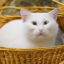

In [35]:
# Create the text tokens to feed to the model
tokens      = model.tokenizer.encode(prompt)
tokens, mask = model.tokenizer.padded_tokens_and_mask(
    tokens, options['text_ctx']
)

# Pack the tokens together into model kwargs
model_kwargs = dict(
    tokens = torch.tensor([tokens] * batch_size, device=device),
    mask   = torch.tensor([mask] * batch_size, dtype=torch.bool, device=device),
)

# Setup guidance function for CLIP model
cond_fn = clip_model.cond_fn([prompt] * batch_size, guidance_scale)

# Sample from the base model
model.del_cache()
samples = diffusion.p_sample_loop(
    model,
    (batch_size, 3, options["image_size"], options["image_size"]),
    device        = device,
    clip_denoised = True,
    progress      = True,
    model_kwargs  = model_kwargs,
    cond_fn       = cond_fn,
)
model.del_cache()

# Show the sampled image(s)
show_images(samples)

## Upsample the 64x64 samples to 256x256

  0%|          | 0/27 [00:00<?, ?it/s]

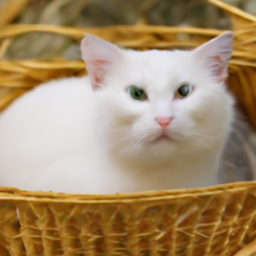

In [36]:
tokens       = model_up.tokenizer.encode(prompt)
tokens, mask = model_up.tokenizer.padded_tokens_and_mask(
    tokens, options_up['text_ctx']
)

# Create the model conditioning dict
model_kwargs = dict(
    # Low-res image to upsample
    low_res = ((samples+1)*127.5).round()/127.5 - 1,

    # Text tokens
    tokens=torch.tensor(
        [tokens] * batch_size, device=device
    ),
    mask=torch.tensor(
        [mask] * batch_size,
        dtype  = torch.bool,
        device = device,
    ),
)

# Sample from the base model
model_up.del_cache()
up_shape  = (batch_size, 3, options_up["image_size"], options_up["image_size"])
up_samples = diffusion_up.ddim_sample_loop(
    model_up,
    up_shape,
    noise=torch.randn(up_shape, device=device) * upsample_temp,
    device=device,
    clip_denoised=True,
    progress=True,
    model_kwargs=model_kwargs,
    cond_fn=None,
)[:batch_size]
model_up.del_cache()

# Show the upsampled image(s)
show_images(up_samples)